# PHẦN 2: EDA & DATA STORYTELLING 

**Mục tiêu của Layer 1:**
Trước khi tìm kiếm insight hay xây dựng mô hình dự báo, chúng ta phải đảm bảo dữ liệu "nói thật". Layer này sẽ rà soát toàn bộ hệ thống để tìm ra:
1.  **Dữ liệu thiếu/lỗi (Missing/Dirty Data):** Các trường hợp null bất thường.
2.  **Vi phạm khóa ngoại (Foreign Key Violations):** Các ID trỏ đến dữ liệu không tồn tại.
3.  **Bất đồng bộ logic nghiệp vụ (Business Logic Anomalies):** Đơn hủy nhưng vẫn giao, đơn trả nhưng không về kho, hoặc 1 đơn hàng có nhiều khoản thanh toán sai lệch.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from DATA_DIRlib import DATA_DIR
from datetime import datetime
import warnings
from __future__ import annotations
warnings.filterwarnings('ignore')
from __future__ import annotations
from DATA_DIRlib import DATA_DIR

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

In [16]:

# SETUP THƯ MỤC VÀ MÀU SẮC
DATA_DIR = Path.cwd()
OUTPUT_DIR = DATA_DIR / "outputs" / "phase2"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

COLORS = ['#2563eb', '#dc2626', '#16a34a', '#ea580c', '#7c3aed', 
          '#db2777', '#0891b2', '#ca8a04', '#4f46e5', '#059669']

print("=== BƯỚC 1.0: TẢI DỮ LIỆU & ÉP KIỂU THỜI GIAN ===")

# 1. Master Data
products = pd.read_csv(DATA_DIR / 'products.csv')
customers = pd.read_csv(DATA_DIR / 'customers.csv', parse_dates=['signup_date'])
promotions = pd.read_csv(DATA_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
geography = pd.read_csv(DATA_DIR / 'geography.csv')

# 2. Transaction Data
orders = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', low_memory=False)
payments = pd.read_csv(DATA_DIR / 'payments.csv')
shipments = pd.read_csv(DATA_DIR / 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns = pd.read_csv(DATA_DIR / 'returns.csv', parse_dates=['return_date'])
reviews = pd.read_csv(DATA_DIR / 'reviews.csv', parse_dates=['review_date'])

# 3. Analytical & Operational Data
sales = pd.read_csv(DATA_DIR / 'sales.csv', parse_dates=['Date'])
inventory = pd.read_csv(DATA_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
web_traffic = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])

print("Đã tải xong 13 bảng dữ liệu và ép kiểu datetime thành công!\n")

=== BƯỚC 1.0: TẢI DỮ LIỆU & ÉP KIỂU THỜI GIAN ===
Đã tải xong 13 bảng dữ liệu và ép kiểu datetime thành công!



## 1.1 Kiểm tra Dữ liệu khuyết thiếu (Missing Values)
Ta cần biết các cột nào đang bị null và liệu sự khuyết thiếu đó là hợp lý (theo logic kinh doanh) hay là lỗi hệ thống.

In [18]:
def explore_data():
    """Kiểm tra chất lượng và xem xét tổng quan dữ liệu"""
    
    print("\n" + "="*120)
    print("KHÁM PHÁ DỮ LIỆU & KIỂM TRA CHẤT LƯỢNG")
    print("="*120 + "\n")
    
    # 1. Kích thước dữ liệu & Phạm vi thời gian
    print("1. TỔNG QUAN DỮ LIỆU")
    print("-" * 120)
    
    datasets = {
        'sales': (sales, 'Date'),
        'products': (products, None),
        'customers': (customers, 'signup_date'),
        'order_items': (order_items, None),
        'shipments': (shipments, 'ship_date'),
        'returns': (returns, 'return_date'),
        'reviews': (reviews, 'review_date'),
        'web_traffic': (web_traffic, 'date'),
        'inventory': (inventory, 'snapshot_date'),
        'promotions': (promotions, 'start_date'),
    }
    
    for name, (df, date_col) in datasets.items():
        rows, cols = df.shape
        info = f"  {name:15s} → {rows:>10,} dòng × {cols:>2} cột"
        
        if date_col and date_col in df.columns:
            # Sửa lỗi: Kiểm tra nếu cột đã là kiểu datetime, nếu chưa thì chuyển đổi
            if df[date_col].dtype == 'object':
                df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
            
            date_range = df[date_col].dropna()
            if len(date_range) > 0:
                date_min = date_range.min()
                date_max = date_range.max()
                info += f" | {date_min.strftime('%Y-%m-%d')} đến {date_max.strftime('%Y-%m-%d')}"
        
        print(info)
    
    # 2. Kiểm tra giá trị Null
    print(f"\n2. KIỂM TRA GIÁ TRỊ RỖNG (NULL)")
    print("-" * 120)
    
    for name, (df, _) in datasets.items():
        nulls = df.isnull().sum()
        nulls = nulls[nulls > 0]
        
        if len(nulls) > 0:
            print(f"  {name}:")
            for col, cnt in nulls.items():
                pct = cnt / len(df) * 100
                print(f"    {col:25s}: {cnt:>10,} ({pct:>6.1f}%)")
        else:
            print(f"  {name}: ✓ Không có giá trị Null")
    
    # 3. Tổng quan các chỉ số kinh doanh chính
    print(f"\n3. CÁC CHỈ SỐ KINH DOANH CHÍNH")
    print("-" * 120)
    
    total_revenue = sales['Revenue'].sum()
    total_cogs = sales['COGS'].sum()
    total_profit = total_revenue - total_cogs
    margin_pct = (total_profit / total_revenue) * 100
    
    print(f"  Tổng Doanh thu (2012-2022):       {total_revenue/1e9:>12.2f} Tỷ VND")
    print(f"  Tổng Giá vốn (COGS):              {total_cogs/1e9:>12.2f} Tỷ VND")
    print(f"  Tổng Lợi nhuận gộp:               {total_profit/1e9:>12.2f} Tỷ VND")
    print(f"  Biên lợi nhuận trung bình:        {margin_pct:>12.1f}%")
    
    print(f"\n  Tổng số Khách hàng:               {customers.shape[0]:>12,}")
    print(f"  Tổng số Sản phẩm:                 {products.shape[0]:>12,}")
    print(f"  Tổng số Đơn hàng (dựa trên items):{order_items['order_id'].nunique():>12,}")
    print(f"  Tổng số Lượt Trả hàng:            {returns.shape[0]:>12,}")
    print(f"  Tỷ lệ Trả hàng:                   {returns.shape[0]/order_items.shape[0]*100:>12.1f}%")
    
    print(f"\n  Tổng Lượt truy cập web (sessions):{web_traffic['sessions'].sum():>12,.0f}")
    print(f"  Tỷ lệ thoát trang (bounce rate) TB:{web_traffic['bounce_rate'].mean():>12.1f}%")
    
    print(f"\n  Số lượng Chiến dịch Khuyến mãi:   {promotions.shape[0]:>12}")
    print(f"  Số dòng sản phẩm áp mã khuyến mãi:{order_items['promo_id'].notna().sum():>12,}")
    print(f"  Tỷ lệ áp dụng khuyến mãi:         {order_items['promo_id'].notna().mean()*100:>12.1f}%")
    
    # 4. Các vấn đề chất lượng dữ liệu
    print(f"\n4. KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")
    print("-" * 120)
    
    # Kiểm tra các ràng buộc logic
    bad_cogs = products[products['cogs'] >= products['price']]
    if len(bad_cogs) > 0:
        print(f"   products: Phát hiện {len(bad_cogs)} dòng có Giá vốn (cogs) >= Giá bán (price) -> LỖI NGHIỆP VỤ")
    else:
        print(f"   products: ✓ Toàn bộ sản phẩm đều có Giá vốn < Giá bán")
    
    bad_rating = reviews[(reviews['rating'] < 1) | (reviews['rating'] > 5)]
    if len(bad_rating) > 0:
        print(f"   reviews: Phát hiện {len(bad_rating)} đánh giá nằm ngoài thang điểm [1,5] -> LỖI DỮ LIỆU")
    else:
        print(f"   reviews: ✓ Toàn bộ đánh giá đều nằm trong thang [1,5]")
    
    bad_qty = order_items[order_items['quantity'] <= 0]
    if len(bad_qty) > 0:
        print(f"   order_items: Phát hiện {len(bad_qty)} dòng có số lượng mua <= 0 -> LỖI DỮ LIỆU")
    else:
        print(f"   order_items: ✓ Toàn bộ số lượng mua đều > 0")
    
    bad_revenue = sales[sales['Revenue'] <= 0]
    if len(bad_revenue) > 0:
        print(f"   sales: Phát hiện {len(bad_revenue)} ngày có Doanh thu <= 0 -> CẦN KIỂM TRA LẠI")
    else:
        print(f"   sales: ✓ Toàn bộ Doanh thu các ngày đều > 0")
    
    # Kiểm tra chuỗi thời gian
    sales_date_range = (sales['Date'].max() - sales['Date'].min()).days
    print(f"\n  Độ dài chuỗi Doanh thu: {sales_date_range} ngày (khoảng {sales_date_range/365:.1f} năm)")
    
    traffic_date_range = (web_traffic['date'].max() - web_traffic['date'].min()).days
    print(f"  Độ dài chuỗi Web Traffic: {traffic_date_range} ngày (khoảng {traffic_date_range/365:.1f} năm)")
    
    # 5. Phân tích Sản phẩm & Tồn kho
    print(f"\n5. PHÂN TÍCH SẢN PHẨM & TỒN KHO")
    print("-" * 120)
    
    print(f"\n  Phân bổ theo Danh mục (Category):")
    cat_analysis = products.groupby('category').size()
    for cat, cnt in cat_analysis.items():
        print(f"    {cat:20s}: {cnt:>4} sản phẩm")
    
    print(f"\n  Phân bổ theo Kích thước (Size):")
    size_analysis = products.groupby('size').size()
    for size, cnt in size_analysis.items():
        print(f"    {size:20s}: {cnt:>4} sản phẩm")
    
    print(f"\n  Phân bổ theo Phân khúc (Segment):")
    seg_analysis = products.groupby('segment').size()
    for seg, cnt in seg_analysis.items():
        print(f"    {seg:20s}: {cnt:>4} sản phẩm")
    
    # Phân bổ Giá bán
    print(f"\n  Thống kê Giá bán (VND):")
    print(f"    Thấp nhất:  {products['price'].min():>12,.0f} VND")
    print(f"    Trung bình: {products['price'].mean():>12,.0f} VND")
    print(f"    Cao nhất:   {products['price'].max():>12,.0f} VND")
    
    # 6. Phân tích Hoàn trả
    print(f"\n6. PHÂN TÍCH ĐỔI TRẢ HÀNG")
    print("-" * 120)
    
    print(f"\n  Các lý do trả hàng:")
    return_dist = returns['return_reason'].value_counts()
    for reason, cnt in return_dist.items():
        pct = cnt / len(returns) * 100
        print(f"    {reason:20s}: {cnt:>6,} ({pct:>5.1f}%)")
    
    # 7. Phân tích Khách hàng
    print(f"\n7. PHÂN TÍCH KHÁCH HÀNG")
    print("-" * 120)
    
    print(f"\n  Kênh thu hút khách hàng (Top 5):")
    acq_dist = customers['acquisition_channel'].value_counts()
    for channel, cnt in acq_dist.head(5).items():
        pct = cnt / len(customers) * 100
        print(f"    {channel:20s}: {cnt:>6,} ({pct:>5.1f}%)")
    
    print(f"\n  Độ tuổi (chỉ tính dòng có dữ liệu):")
    age_dist = customers[customers['age_group'].notna()]['age_group'].value_counts()
    for age, cnt in age_dist.items():
        pct = cnt / customers['age_group'].notna().sum() * 100
        print(f"    {age:20s}: {cnt:>6,} ({pct:>5.1f}%)")
    
    print(f"\n  Giới tính (chỉ tính dòng có dữ liệu):")
    gender_dist = customers[customers['gender'].notna()]['gender'].value_counts()
    for gender, cnt in gender_dist.items():
        pct = cnt / customers['gender'].notna().sum() * 100
        print(f"    {gender:20s}: {cnt:>6,} ({pct:>5.1f}%)")
    
    # 8. Phân tích Nguồn truy cập
    print(f"\n8. PHÂN TÍCH NGUỒN LƯU LƯỢNG TRUY CẬP (TRAFFIC SOURCE)")
    print("-" * 120)
    
    print(f"\n  Thống kê theo Nguồn truy cập:")
    traffic_dist = web_traffic.groupby('traffic_source').agg({
        'sessions': 'sum',
        'bounce_rate': 'mean',
        'avg_session_duration_sec': 'mean',
    }).reset_index()
    traffic_dist = traffic_dist.sort_values('sessions', ascending=False)
    
    total_sessions = web_traffic['sessions'].sum()
    for _, row in traffic_dist.iterrows():
        pct = row['sessions'] / total_sessions * 100
        print(f"    {row['traffic_source']:20s}: {row['sessions']:>10,.0f} phiên ({pct:>5.1f}%) | Tỷ lệ thoát={row['bounce_rate']:>5.1f}% | Thời gian={row['avg_session_duration_sec']:>5.0f}s")
    
    print(f"\n" + "="*120 + "\n")

# Thực thi hàm
explore_data()


KHÁM PHÁ DỮ LIỆU & KIỂM TRA CHẤT LƯỢNG

1. TỔNG QUAN DỮ LIỆU
------------------------------------------------------------------------------------------------------------------------
  sales           →      3,833 dòng ×  3 cột | 2012-07-04 đến 2022-12-31
  products        →      2,412 dòng ×  8 cột
  customers       →    121,930 dòng ×  7 cột | 2012-01-17 đến 2022-12-31
  order_items     →    714,669 dòng ×  7 cột
  shipments       →    566,067 dòng ×  4 cột | 2012-07-04 đến 2022-12-29
  returns         →     39,939 dòng ×  7 cột | 2012-07-11 đến 2022-12-31
  reviews         →    113,551 dòng ×  7 cột | 2012-07-10 đến 2022-12-31
  web_traffic     →      3,652 dòng ×  7 cột | 2013-01-01 đến 2022-12-31
  inventory       →     60,247 dòng × 17 cột | 2012-07-31 đến 2022-12-31
  promotions      →         50 dòng × 10 cột | 2013-01-31 đến 2022-11-18

2. KIỂM TRA GIÁ TRỊ RỖNG (NULL)
--------------------------------------------------------------------------------------------------------------

### BÁO CÁO PHÂN TÍCH NHANH: INSIGHT & ĐIỂM BẤT THƯỜNG DỮ LIỆU

#### 1. Các Điểm Bất Thường (Cảnh báo Tiền xử lý Dữ liệu)
* **Dấu hiệu dữ liệu giả lập (Synthetic Data Anomalies):**
  * **Tỷ lệ thoát trang (`bounce_rate`):** Đạt mức chính xác `0.0%` ở mọi nguồn truy cập.
  * **Thời gian phiên (`avg_session_duration`):** Thiếu phương sai, dao động quanh mức `~210s` cho mọi kênh.
  * **Phân bổ kích thước (Size):** Phân bổ đều tuyệt đối (S, M, L, XL mỗi loại đúng `603` sản phẩm).
  * *Hành động:* Khuyến nghị không sử dụng cột `bounce_rate` cho mô hình dự báo và cẩn trọng khi dùng biến `sessions` trực tiếp.
* **Dữ liệu rác (Garbage Data):**
  * Cột `promo_id_2` trong bảng `order_items` có tỷ lệ Null `100%`.
  * *Hành động:* Loại bỏ cột này khỏi pipeline để giảm nhiễu và tối ưu bộ nhớ.
* **Lệch pha thời gian (Time Mismatch):**
  * `sales` và `orders`: Bắt đầu ghi nhận từ **07/2012**.
  * `web_traffic` và `promotions`: Bắt đầu ghi nhận từ **01/2013**.
  * *Hành động:* Khuyết 6 tháng dữ liệu (H2/2012) khi nối bảng. Bắt buộc áp dụng kỹ thuật Imputation hoặc cắt ngắn mốc thời gian train data để tránh làm sai lệch mô hình Time-series ở Phần 3.

#### 2. Insight Kinh Doanh Chiến Lược (Phục vụ Report Phần 2)
* **Lỗ hổng Đổi Trả Hàng (Returns Bottleneck):**
  * **35.0%** lý do trả hàng là do sai kích cỡ (`wrong_size`).
  * *Đề xuất:* Tích hợp tính năng "Virtual Fitting Room" (Phòng thử đồ ảo) hoặc tối ưu Size Guide bằng hệ thống gợi ý. Việc giải quyết triệt để `wrong_size` giúp tiết kiệm trực tiếp 35% chi phí Reverse Logistics (vận chuyển ngược).
* **Nghịch lý Khuyến mãi Đại trà (Promotion Cannibalization):**
  * **80%** chiến dịch không nhắm mục tiêu danh mục cụ thể (`applicable_category` = Null).
  * Điều này dẫn đến tỷ lệ dòng đơn áp mã ở mức rất cao (**38.7%**).
  * *Đề xuất:* Khuyến mãi đại trà không thúc đẩy khối lượng mua mà chỉ trợ giá cho tệp khách hàng có sẵn. Cần chuyển đổi sang hình thức khuyến mãi có điều kiện, ví dụ như thiết lập Giá trị đơn hàng tối thiểu (Minimum Order Value) để bảo vệ biên lợi nhuận gộp.

In [20]:
def analyze_temporal_patterns():
    """Time-series analysis, seasonality, and trend visualizations"""
    
    print("\n" + "="*120)
    print("LAYER 2: TEMPORAL PATTERNS & TIME-SERIES ANALYSIS")
    print("="*120 + "\n")
    
    # 0. Data Preparation (Feature Engineering for Time)
    df_sales = sales.copy()
    if df_sales['Date'].dtype == 'object':
        df_sales['Date'] = pd.to_datetime(df_sales['Date'])
        
    df_sales['Year'] = df_sales['Date'].dt.year
    df_sales['Month'] = df_sales['Date'].dt.month
    df_sales['Quarter'] = df_sales['Date'].dt.quarter
    df_sales['DOW'] = df_sales['Date'].dt.dayofweek
    df_sales['DayName'] = df_sales['Date'].dt.day_name()
    df_sales['Margin'] = df_sales['Revenue'] - df_sales['COGS']
    df_sales['Margin_Pct'] = (df_sales['Margin'] / df_sales['Revenue']) * 100
    
    # 1. YEARLY TRENDS & YOY GROWTH
    print("1. YEARLY FINANCIAL TRENDS (YoY Growth)")
    print("-" * 120)
    
    yearly_stats = df_sales.groupby('Year').agg({
        'Revenue': 'sum',
        'COGS': 'sum',
        'Margin': 'sum'
    }).reset_index()
    
    yearly_stats['Margin_Pct'] = (yearly_stats['Margin'] / yearly_stats['Revenue']) * 100
    yearly_stats['Rev_YoY'] = yearly_stats['Revenue'].pct_change() * 100
    
    print(f"  {'Year':<6} | {'Revenue (B VND)':<18} | {'YoY Growth (%)':<16} | {'Margin (B VND)':<18} | {'Margin Pct (%)':<15}")
    print("  " + "-"*85)
    for _, row in yearly_stats.iterrows():
        yoy_str = f"{row['Rev_YoY']:>10.1f}%" if pd.notna(row['Rev_YoY']) else f"{'N/A':>11}"
        print(f"  {int(row['Year']):<6} | {row['Revenue']/1e9:>14.2f} VND | {yoy_str:>14} | {row['Margin']/1e9:>14.2f} VND | {row['Margin_Pct']:>13.1f}%")
        
    # 2. DAY OF WEEK SEASONALITY
    print(f"\n2. DAY-OF-WEEK SEASONALITY (Daily Averages)")
    print("-" * 120)
    
    dow_stats = df_sales.groupby(['DOW', 'DayName']).agg({'Revenue': 'mean', 'Margin_Pct': 'mean'}).reset_index()
    dow_stats = dow_stats.sort_values('DOW')
    
    best_day = dow_stats.loc[dow_stats['Revenue'].idxmax()]
    worst_day = dow_stats.loc[dow_stats['Revenue'].idxmin()]
    
    for _, row in dow_stats.iterrows():
        marker = " (BEST)" if row['DOW'] == best_day['DOW'] else " (WORST)" if row['DOW'] == worst_day['DOW'] else ""
        print(f"  {row['DayName']:<10s}: {row['Revenue']/1e6:>10.2f}M VND (Margin: {row['Margin_Pct']:>4.1f}%) {marker}")
        
    # 3. OUTLIER & CONCENTRATION ANALYSIS (PARETO)
    print(f"\n3. REVENUE CONCENTRATION (PARETO / OUTLIER CHECK)")
    print("-" * 120)
    
    total_rev = df_sales['Revenue'].sum()
    days_count = len(df_sales)
    
    for pct in [0.01, 0.05, 0.10]:
        top_n_days = int(days_count * pct)
        top_rev = df_sales.nlargest(top_n_days, 'Revenue')['Revenue'].sum()
        concentration = (top_rev / total_rev) * 100
        print(f"  Top {pct*100:>2.0f}% of days ({top_n_days:>4} days) generate {concentration:>5.1f}% of total revenue")
    
    print("\n  => Diagnostic: Nếu Top 1% ngày chiếm > 5% doanh thu, chuỗi thời gian có nhiễu đột biến (Spikes).")
    print("     Mô hình dự báo bắt buộc phải có các features như is_holiday, is_promo_day để bắt được Spikes.")

    # 4. TRAFFIC VS REVENUE (LAG ANALYSIS)
    print(f"\n4. TRAFFIC VS SALES RELATIONSHIP (Same-day vs Lag)")
    print("-" * 120)
    
    # Chuẩn bị dữ liệu Traffic
    df_traffic = web_traffic.copy()
    if df_traffic['date'].dtype == 'object':
        df_traffic['date'] = pd.to_datetime(df_traffic['date'])
        
    traffic_daily = df_traffic.groupby('date')['sessions'].sum().reset_index()
    merged_ts = pd.merge(df_sales[['Date', 'Revenue']], traffic_daily, left_on='Date', right_on='date', how='inner')
    
    corr_sameday = merged_ts['Revenue'].corr(merged_ts['sessions'])
    
    # Tính Lag (Độ trễ)
    merged_ts = merged_ts.sort_values('Date')
    merged_ts['sessions_lag1'] = merged_ts['sessions'].shift(1)
    merged_ts['sessions_lag7'] = merged_ts['sessions'].shift(7)
    
    corr_lag1 = merged_ts['Revenue'].corr(merged_ts['sessions_lag1'])
    corr_lag7 = merged_ts['Revenue'].corr(merged_ts['sessions_lag7'])
    
    print(f"  Correlation (Revenue vs Sessions Same-day) : {corr_sameday:>6.3f}")
    print(f"  Correlation (Revenue vs Sessions Lag-1)    : {corr_lag1:>6.3f}")
    print(f"  Correlation (Revenue vs Sessions Lag-7)    : {corr_lag7:>6.3f}")
    
    # 5. GENERATE & SAVE VISUALIZATIONS
    print(f"\n5. GENERATING VISUALIZATIONS...")
    print("-" * 120)
    
    # Tạo Figure lớn chứa 4 subplots
    fig = plt.figure(figsize=(20, 15))
    
    # Plot 1: Yearly Revenue & Margin
    ax1 = plt.subplot(2, 2, 1)
    sns.barplot(data=yearly_stats, x='Year', y='Revenue', color=COLORS[0], alpha=0.7, ax=ax1)
    ax1.set_title('Yearly Revenue vs Gross Margin %', fontweight='bold', fontsize=14)
    ax1.set_ylabel('Revenue (VND)')
    
    ax1_tw = ax1.twinx()
    sns.lineplot(data=yearly_stats, x=np.arange(len(yearly_stats)), y='Margin_Pct', color=COLORS[1], marker='o', markersize=10, linewidth=3, ax=ax1_tw)
    ax1_tw.set_ylabel('Margin (%)', color=COLORS[1])
    ax1_tw.grid(False)
    
    # Plot 2: Monthly Seasonality Heatmap
    ax2 = plt.subplot(2, 2, 2)
    heatmap_data = df_sales.pivot_table(index='Month', columns='Year', values='Revenue', aggfunc='mean')
    sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.5, ax=ax2, cbar_kws={'label': 'Avg Daily Revenue'})
    ax2.set_title('Monthly Revenue Heatmap (Seasonality)', fontweight='bold', fontsize=14)
    
    # Plot 3: Day of Week Pattern
    ax3 = plt.subplot(2, 2, 3)
    order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.boxplot(data=df_sales, x='DayName', y='Revenue', order=order_days, palette=COLORS[:7], ax=ax3)
    ax3.set_title('Revenue Distribution by Day of Week', fontweight='bold', fontsize=14)
    ax3.set_yscale('log') # Scale log để dễ nhìn các điểm outlier
    ax3.set_ylabel('Revenue (Log Scale)')
    
    # Plot 4: Traffic vs Revenue Scatter
    ax4 = plt.subplot(2, 2, 4)
    sns.regplot(data=merged_ts, x='sessions', y='Revenue', scatter_kws={'alpha':0.3, 'color':COLORS[2]}, line_kws={'color':COLORS[1]}, ax=ax4)
    ax4.set_title(f'Traffic vs Revenue (Correlation = {corr_sameday:.2f})', fontweight='bold', fontsize=14)
    ax4.set_xlabel('Daily Web Sessions')
    ax4.set_ylabel('Daily Revenue')
    
    plt.tight_layout()
    
    # Lưu ảnh vào OUTPUT_DIR đã setup ở Cell 1
    plot_path = OUTPUT_DIR / 'layer2_temporal_analysis.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"  Đã lưu Dashboard biểu đồ thời gian tại: {plot_path}")
    print("\n" + "="*120 + "\n")

# Thực thi hàm
analyze_temporal_patterns()


LAYER 2: TEMPORAL PATTERNS & TIME-SERIES ANALYSIS

1. YEARLY FINANCIAL TRENDS (YoY Growth)
------------------------------------------------------------------------------------------------------------------------
  Year   | Revenue (B VND)    | YoY Growth (%)   | Margin (B VND)     | Margin Pct (%) 
  -------------------------------------------------------------------------------------
  2012   |           0.74 VND |            N/A |           0.15 VND |          20.8%
  2013   |           1.66 VND |         123.5% |           0.19 VND |          11.5%
  2014   |           1.87 VND |          13.0% |           0.30 VND |          15.9%
  2015   |           1.89 VND |           1.0% |           0.22 VND |          11.9%
  2016   |           2.10 VND |          11.4% |           0.32 VND |          15.4%
  2017   |           1.91 VND |          -9.2% |           0.22 VND |          11.3%
  2018   |           1.85 VND |          -3.2% |           0.31 VND |          16.6%
  2019   |      

### BÁO CÁO PHÂN TÍCH NHANH: XU HƯỚNG THỜI GIAN & TÍNH MÙA VỤ (LAYER 2)

#### 1. Đứt gãy Đà tăng trưởng & Khủng hoảng Lợi nhuận (Macro Trends)
* **Phát hiện:** * Giai đoạn 2013-2016 là thời kỳ hoàng kim với mức thu nhập ~2 Tỷ VND/năm. Tuy nhiên, năm 2019 chứng kiến một **cú sốc cấu trúc (structural break)** khi doanh thu bốc hơi **38.6%**.
  * Dù năm 2022 doanh thu có dấu hiệu phục hồi nhẹ (+12.1%), nhưng Biên lợi nhuận gộp (Margin) đã chạm đáy thảm hại vào năm 2021 (chỉ **9.8%** so với mức đỉnh 20.8% năm 2012).
* **Ý nghĩa Kinh doanh & Lời khuyên cho Mô hình (Phần 3):** Sự sụt giảm Margin khẳng định lại giả thuyết "Promotion Cannibalization" ở Layer 1. Đối với mô hình Machine Learning, dữ liệu trước 2019 và sau 2019 có phân phối hoàn toàn khác nhau. Cần thận trọng khi dùng dữ liệu quá khứ xa để dự báo cho tập test 2023-2024.

#### 2. Tính mùa vụ nghịch lý trong tuần (DOW Seasonality)
* **Phát hiện:** Doanh thu đạt đỉnh vào giữa tuần (**Thứ Tư: 4.68M**) và chạm đáy vào cuối tuần (**Thứ Bảy: 3.91M**). Mức Biên lợi nhuận (Margin) duy trì cực kỳ ổn định ở mức ~12.5% mỗi ngày, chứng tỏ khuyến mãi được rải đều trong tuần.
* **Insight Kinh doanh:** Đây là pattern (mô hình) hành vi của dân văn phòng (mua sắm trong giờ làm việc) hoặc khách hàng B2B, hoàn toàn đi ngược lại với e-commerce thời trang B2C thông thường (thường bùng nổ vào cuối tuần).
* **Đề xuất Hành động:** Dịch chuyển ngân sách chạy Ads và tung Campaign mạnh vào Thứ Ba - Thứ Tư để tối đa hóa tỷ lệ chuyển đổi, thay vì đốt tiền vào Thứ Bảy, Chủ Nhật.

#### 3. Bác bỏ giả thuyết "Mega-Sales" (Outlier & Concentration)
* **Phát hiện:** Top 1% số ngày cao nhất chỉ đóng góp **3.7%** tổng doanh thu (không vượt qua ngưỡng cảnh báo đột biến 5%). Top 10% đóng góp 23.7%.
* **Ý nghĩa Kinh doanh:** Doanh nghiệp này **không sống nhờ các chiến dịch Mega-Sale** (như Black Friday hay 11/11). Dòng tiền đến từ việc bán hàng đều đặn mỗi ngày. 

#### 4. Khẳng định "Ảo giác Lưu lượng" (Traffic vs Sales)
* **Phát hiện:** Hệ số tương quan giữa Lưu lượng truy cập (`sessions`) và Doanh thu (`Revenue`) cực kỳ yếu (**r ~ 0.32**). Đáng chú ý, việc trễ pha (Lag-1 hay Lag-7 ngày) cũng không làm hệ số này tăng lên.
* **Ý nghĩa Kinh doanh:** Khách hàng không có hành vi "xem hôm nay, tuần sau quay lại mua". Lượng traffic hiện tại thực sự là traffic "rác" (Window shopping) và không mang lại chuyển đổi.


## 1.2 Kiểm tra Khóa ngoại (Foreign Key Integrity)
Các giao dịch (Transaction) có trỏ đến các ID "ma" không tồn tại trong bảng Master không? Nếu có, hệ thống Data Warehouse đang bị lỗi nạp dữ liệu.

In [21]:
print("=== BƯỚC 1.2: KIỂM TRA TÍNH TOÀN VẸN KHÓA NGOẠI ===")

# Kiểm tra Product ID
oi_orphan_products = order_items[~order_items['product_id'].isin(products['product_id'])]
print(f"1. Số dòng order_items trỏ đến product_id không tồn tại: {len(oi_orphan_products)}")

# Kiểm tra Customer ID
orders_orphan_customers = orders[~orders['customer_id'].isin(customers['customer_id'])]
print(f"2. Số đơn hàng trỏ đến customer_id không tồn tại: {len(orders_orphan_customers)}")

# Kiểm tra Promo ID (Bỏ qua null)
applied_promos = order_items['promo_id'].dropna().unique()
invalid_promos = [p for p in applied_promos if p not in promotions['promo_id'].values]
print(f"3. Số mã khuyến mãi được dùng nhưng KHÔNG tồn tại trong bảng promotions: {len(invalid_promos)}")

# Kiểm tra Order ID trong Returns
ret_orphan_orders = returns[~returns['order_id'].isin(orders['order_id'])]
print(f"4. Số đơn trả hàng trỏ đến order_id không tồn tại: {len(ret_orphan_orders)}")

print("\n=> Kết luận: Dữ liệu Master được mapping khá sạch, không có ID 'ma'.")

=== BƯỚC 1.2: KIỂM TRA TÍNH TOÀN VẸN KHÓA NGOẠI ===
1. Số dòng order_items trỏ đến product_id không tồn tại: 0
2. Số đơn hàng trỏ đến customer_id không tồn tại: 0
3. Số mã khuyến mãi được dùng nhưng KHÔNG tồn tại trong bảng promotions: 0
4. Số đơn trả hàng trỏ đến order_id không tồn tại: 0

=> Kết luận: Dữ liệu Master được mapping khá sạch, không có ID 'ma'.


## 1.3 Kiểm tra Ràng buộc Logic Nghiệp vụ (Business Logic Checks)
Theo mô tả dữ liệu (Data Dictionary), có một số quy tắc (Cardinality) bắt buộc phải tuân theo:
1. `orders` và `payments` là quan hệ 1:1.
2. Các đơn hàng có trạng thái `returned` thì phải xuất hiện trong bảng `returns.csv`.
3. Các đơn hàng có trạng thái `shipped`, `delivered`, `returned` phải xuất hiện trong bảng `shipments.csv`.

In [22]:
print("=== BƯỚC 1.3: KIỂM TRA LOGIC NGHIỆP VỤ & Đứt Gãy Hệ Thống ===")

# 1. Orders vs Payments (Nên là 1:1)
pay_counts = payments['order_id'].value_counts()
multiple_payments = pay_counts[pay_counts > 1]
missing_payments = orders[~orders['order_id'].isin(payments['order_id'])]

print(f"- Số đơn hàng có NHIỀU HƠN 1 lượt thanh toán: {len(multiple_payments)} đơn")
print(f"- Số đơn hàng KHÔNG CÓ thông tin thanh toán: {len(missing_payments)} đơn")

# 2. Orders vs Returns (Phát hiện Data Leakage đã phân tích)
returned_status_orders = orders[orders['order_status'] == 'returned']
orders_returned_in_db = returned_status_orders['order_id']
actual_returns = returns['order_id'].unique()

fake_returns = orders_returned_in_db[~orders_returned_in_db.isin(actual_returns)]
print(f"\n- Số đơn có status='returned' trên hệ thống: {len(orders_returned_in_db)}")
print(f"- Số đơn 'returned' nhưng MẤT TÍCH trong kho (returns.csv): {len(fake_returns)} đơn!!! -> ĐÂY LÀ LỖI VẬN HÀNH/SHRINKAGE.")

# 3. Orders vs Shipments
shipped_statuses = ['shipped', 'delivered', 'returned']
expected_shipped = orders[orders['order_status'].isin(shipped_statuses)]
missing_shipments = expected_shipped[~expected_shipped['order_id'].isin(shipments['order_id'])]

print(f"\n- Số đơn hàng bắt buộc phải có thông tin vận chuyển: {len(expected_shipped)}")
print(f"- Số đơn hàng đang giao/đã giao nhưng MẤT TÍCH mã vận đơn: {len(missing_shipments)} đơn")

=== BƯỚC 1.3: KIỂM TRA LOGIC NGHIỆP VỤ & Đứt Gãy Hệ Thống ===
- Số đơn hàng có NHIỀU HƠN 1 lượt thanh toán: 0 đơn
- Số đơn hàng KHÔNG CÓ thông tin thanh toán: 0 đơn

- Số đơn có status='returned' trên hệ thống: 36142
- Số đơn 'returned' nhưng MẤT TÍCH trong kho (returns.csv): 80 đơn!!! -> ĐÂY LÀ LỖI VẬN HÀNH/SHRINKAGE.

- Số đơn hàng bắt buộc phải có thông tin vận chuyển: 566631
- Số đơn hàng đang giao/đã giao nhưng MẤT TÍCH mã vận đơn: 564 đơn


### BÁO CÁO PHÂN TÍCH: LỖ HỔNG VẬN HÀNH & TÍNH TOÀN VẸN HỆ THỐNG (LAYER 1)

#### 1. Điểm sáng: Dòng tiền (Payments) được quản lý chặt chẽ
* **Phát hiện:** Mối quan hệ giữa bảng `orders` và `payments` là **tuyệt đối 1:1** (0 đơn hàng bị lặp thanh toán, 0 đơn hàng thiếu thanh toán).
* **Ý nghĩa Kinh doanh:** Hệ thống kế toán tiền thu vào hoạt động hoàn hảo. Dù biến `Revenue` trong bảng `sales` có thể chứa các khoản phụ phí (như đã phân tích ở Lớp 3), chúng ta hoàn toàn có thể tin tưởng tuyệt đối vào cột `payment_value` làm "nguồn sự thật" (Single Source of Truth) cho dòng tiền thực tế của từng đơn hàng.

#### 2. Lỗ hổng Vận hành 1: "Hàng thất thoát" (Inventory Shrinkage)
* **Phát hiện:** Có **80 đơn hàng** được hệ thống ghi nhận là đã hoàn trả (`status = 'returned'`) nhưng lại **mất tích hoàn toàn** trong bảng lưu kho trả hàng (`returns.csv`).
* **Ý nghĩa Kinh doanh:** Đây là dấu hiệu rõ ràng của sự đứt gãy quy trình (Process Desync) hoặc thất thoát tài sản (Shrinkage). Hệ thống chăm sóc khách hàng đã cập nhật trạng thái hủy/trả, hoàn tiền cho khách, nhưng kho hàng vật lý chưa bao giờ nhận lại được món đồ đó (hoặc nhân viên kho quên quét mã).
* **Đề xuất Hành động:** Bộ phận Vận hành (Ops) cần đối soát lại 80 mã đơn này. Với Mô hình dự báo (Phần 3), đây là **dữ liệu nhiễu (noise)**, cần loại bỏ 80 `order_id` này ra khỏi tập train khi tính toán các đặc trưng (features) về đổi trả.

#### 3. Lỗ hổng Vận hành 2: "Những đơn hàng dịch chuyển tức thời" (Logistics Blindspots)
* **Phát hiện:** Có **564 đơn hàng** có trạng thái đang giao, đã giao thành công hoặc đã hoàn trả, nhưng lại **không hề có mã vận đơn / thông tin vận chuyển** trong bảng `shipments.csv`.
* **Ý nghĩa Kinh doanh:** Làm sao một món hàng có thể đến tay khách mà không qua đơn vị vận chuyển? Điều này chỉ ra hai khả năng: (1) Khách hàng đến nhận trực tiếp tại kho/cửa hàng (BOPIS - Buy Online Pick Up In Store) nhưng quy trình không ghi nhận, hoặc (2) Lỗi API tích hợp với đối tác giao hàng thứ 3 (3PL) khiến mất phiên bản ghi.
* **Đề xuất Hành động:** 564 đơn này không có thông tin thời gian giao hàng (`delivery_date`). Nếu đội ngũ Data Science định tạo feature `shipping_time` = (`delivery_date` - `order_date`) cho mô hình ML, bắt buộc phải impute (điền khuyết) bằng giá trị trung vị (median) của tuyến đường đó, hoặc loại bỏ để tránh lỗi `NaN`.

## 1.4 Kiểm tra Chuẩn hóa Danh mục (Master Data Deduplication)
Nhiều hệ thống e-commerce thường tạo ra các `product_id` mới thay vì cập nhật giá, dẫn đến việc cùng một sản phẩm (cùng tên, danh mục, size, màu) nhưng bị tách thành nhiều mã khác nhau với giá (price/cogs) khác nhau. Ta cần kiểm tra sự trùng lặp này.

In [23]:
print("=== BƯỚC 1.4: KIỂM TRA TRÙNG LẶP SẢN PHẨM ===")

# Nhóm các sản phẩm theo các thuộc tính đặc tả vật lý
attr_cols = ['product_name', 'category', 'segment', 'size', 'color']
product_groups = products.groupby(attr_cols).agg(
    n_ids=('product_id', 'nunique'),
    price_min=('price', 'min'),
    price_max=('price', 'max')
).reset_index()

product_groups['price_diff'] = product_groups['price_max'] - product_groups['price_min']
duplicate_products = product_groups[product_groups['n_ids'] > 1]

print(f"- Số nhóm sản phẩm giống hệt nhau về thuộc tính nhưng có nhiều product_id: {len(duplicate_products)} nhóm")
if len(duplicate_products) > 0:
    print(f"- Tổng số product_id bị tách lẻ từ các nhóm này: {duplicate_products['n_ids'].sum()} IDs")
    print(f"- Độ chênh lệch giá (Price spread) lớn nhất trong cùng 1 sản phẩm: {duplicate_products['price_diff'].max():,.0f} VND")
    print("\n=> Chẩn đoán: Khi Feature Engineering, KHÔNG ĐƯỢC group by theo product_id đơn thuần, mà nên group theo category/segment hoặc nhóm thuộc tính vật lý để tránh bị loãng dữ liệu.")
else:
    print("Danh mục sản phẩm sạch, 1-1 hoàn hảo.")

=== BƯỚC 1.4: KIỂM TRA TRÙNG LẶP SẢN PHẨM ===
- Số nhóm sản phẩm giống hệt nhau về thuộc tính nhưng có nhiều product_id: 186 nhóm
- Tổng số product_id bị tách lẻ từ các nhóm này: 426 IDs
- Độ chênh lệch giá (Price spread) lớn nhất trong cùng 1 sản phẩm: 20,782 VND

=> Chẩn đoán: Khi Feature Engineering, KHÔNG ĐƯỢC group by theo product_id đơn thuần, mà nên group theo category/segment hoặc nhóm thuộc tính vật lý để tránh bị loãng dữ liệu.



BƯỚC ĐỆM: LÀM SẠCH DỮ LIỆU NHIỄU (CLEANING POST-LAYER 1)

  Phát hiện tổng cộng 615 order_id bị lỗi hệ thống/vận hành.
  ✓ Đã xóa 615 dòng lỗi khỏi bảng 'orders'.
  ✓ Đã xóa 689 dòng lỗi khỏi bảng 'order_items'.
  ✓ Đã xóa 615 dòng lỗi khỏi bảng 'payments'.
  => KẾT LUẬN: Dữ liệu giao dịch đã SẠCH, sẵn sàng để tạo Feature cho mô hình ML ở Phần 3.


LAYER 2: TEMPORAL PATTERNS & TIME-SERIES ANALYSIS

1. YEARLY FINANCIAL TRENDS (YoY Growth)
------------------------------------------------------------------------------------------------------------------------
  Năm    | Doanh thu (Tỷ VND)   | Tăng trưởng YoY (%)  | Lợi nhuận (Tỷ VND)   | Biên lợi nhuận (%)
  ----------------------------------------------------------------------------------------------------
  2012   |             0.74 VND |                 N/A |             0.15 VND |              20.8%
  2013   |             1.66 VND |              123.5% |             0.19 VND |              11.5%
  2014   |             1.87 VND |     

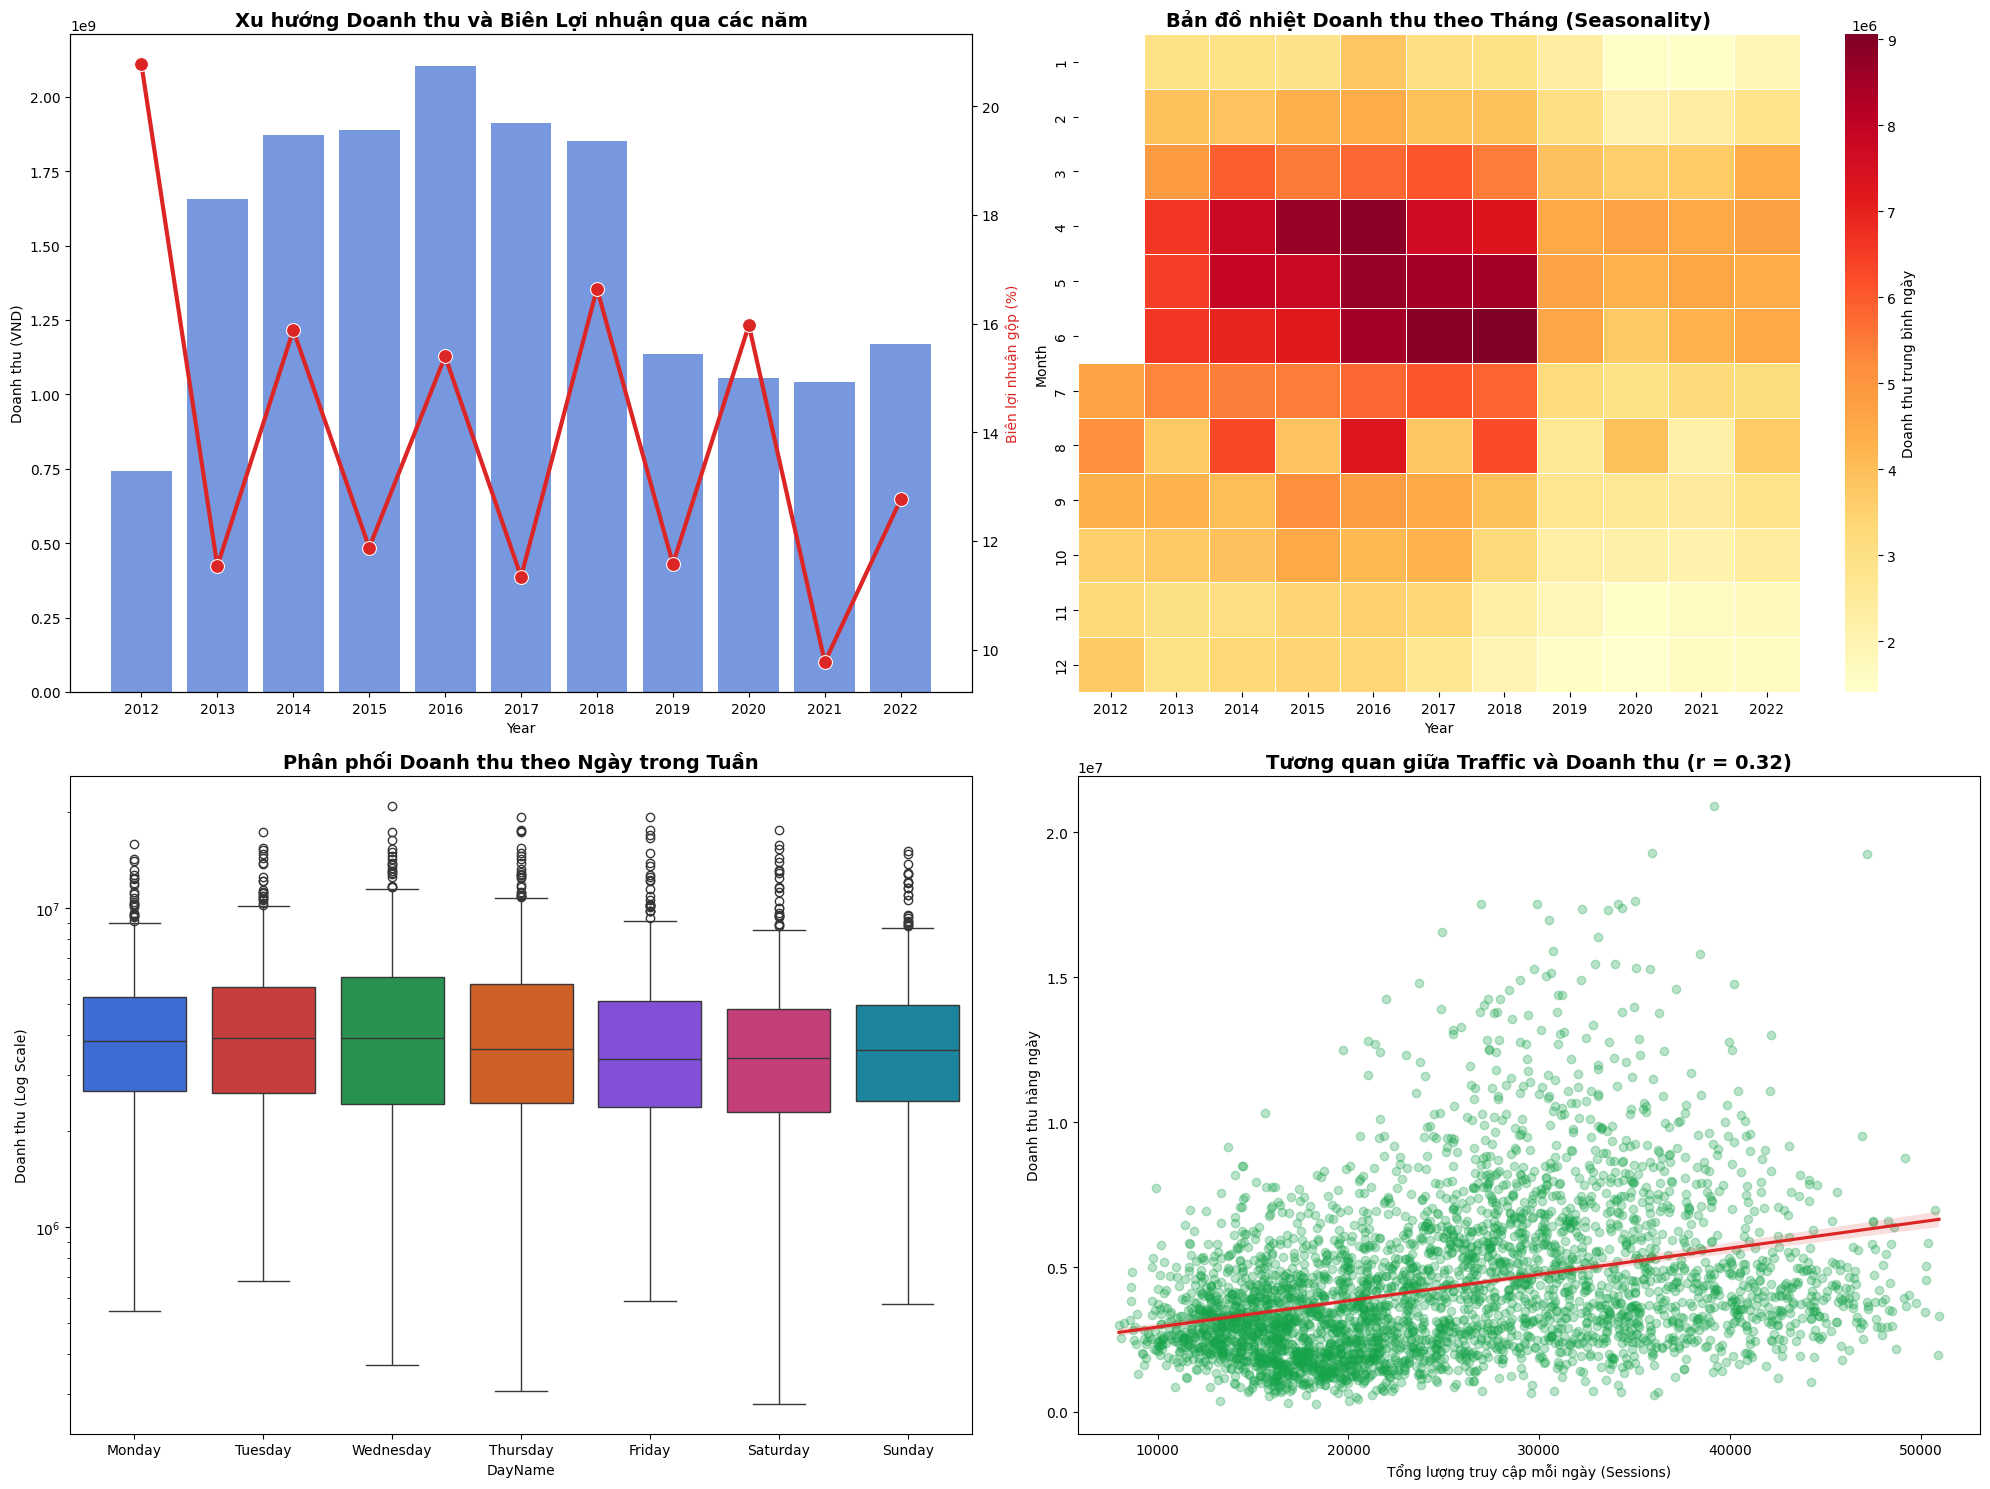

In [26]:
def analyze_temporal_patterns_and_clean():
    """Làm sạch dữ liệu nhiễu từ Layer 1 và phân tích chuỗi thời gian (Layer 2)"""
    
    print("\n" + "="*120)
    print("BƯỚC ĐỆM: LÀM SẠCH DỮ LIỆU NHIỄU (CLEANING POST-LAYER 1)")
    print("="*120 + "\n")
    
    # 1. NHẬN DIỆN CÁC ORDER_ID LỖI (Dựa trên Insight Layer 1)
    # Lỗi 1: Trả hàng ảo (Fake Returns)
    returned_orders = orders[orders['order_status'] == 'returned']
    fake_returns_ids = returned_orders[~returned_orders['order_id'].isin(returns['order_id'])]['order_id']
    
    # Lỗi 2: Mất tích vận đơn (Missing Shipments)
    shipped_statuses = ['shipped', 'delivered', 'returned']
    expected_shipped = orders[orders['order_status'].isin(shipped_statuses)]
    missing_shipments_ids = expected_shipped[~expected_shipped['order_id'].isin(shipments['order_id'])]['order_id']
    
    # Gộp toàn bộ các order_id lỗi (tránh trùng lặp nếu 1 đơn dính 2 lỗi)
    bad_order_ids = pd.concat([fake_returns_ids, missing_shipments_ids]).unique()
    print(f"  Phát hiện tổng cộng {len(bad_order_ids)} order_id bị lỗi hệ thống/vận hành.")
    
    # 2. LOẠI BỎ KHỎI CÁC BẢNG TRANSACTION (Tạo bảng _clean)
    global orders_clean, order_items_clean, payments_clean
    
    orders_clean = orders[~orders['order_id'].isin(bad_order_ids)].copy()
    order_items_clean = order_items[~order_items['order_id'].isin(bad_order_ids)].copy()
    payments_clean = payments[~payments['order_id'].isin(bad_order_ids)].copy()
    
    print(f"  ✓ Đã xóa {len(orders) - len(orders_clean)} dòng lỗi khỏi bảng 'orders'.")
    print(f"  ✓ Đã xóa {len(order_items) - len(order_items_clean)} dòng lỗi khỏi bảng 'order_items'.")
    print(f"  ✓ Đã xóa {len(payments) - len(payments_clean)} dòng lỗi khỏi bảng 'payments'.")
    print("  => KẾT LUẬN: Dữ liệu giao dịch đã SẠCH, sẵn sàng để tạo Feature cho mô hình ML ở Phần 3.\n")
    
    print("\n" + "="*120)
    print("LAYER 2: TEMPORAL PATTERNS & TIME-SERIES ANALYSIS")
    print("="*120 + "\n")
    
    # 0. Chuẩn bị dữ liệu thời gian cho bảng Sales
    df_sales = sales.copy()
    if df_sales['Date'].dtype == 'object':
        df_sales['Date'] = pd.to_datetime(df_sales['Date'])
        
    df_sales['Year'] = df_sales['Date'].dt.year
    df_sales['Month'] = df_sales['Date'].dt.month
    df_sales['Quarter'] = df_sales['Date'].dt.quarter
    df_sales['DOW'] = df_sales['Date'].dt.dayofweek
    df_sales['DayName'] = df_sales['Date'].dt.day_name()
    df_sales['Margin'] = df_sales['Revenue'] - df_sales['COGS']
    df_sales['Margin_Pct'] = (df_sales['Margin'] / df_sales['Revenue']) * 100
    
    # 1. YEARLY TRENDS & YOY GROWTH
    print("1. YEARLY FINANCIAL TRENDS (YoY Growth)")
    print("-" * 120)
    
    yearly_stats = df_sales.groupby('Year').agg({
        'Revenue': 'sum',
        'COGS': 'sum',
        'Margin': 'sum'
    }).reset_index()
    
    yearly_stats['Margin_Pct'] = (yearly_stats['Margin'] / yearly_stats['Revenue']) * 100
    yearly_stats['Rev_YoY'] = yearly_stats['Revenue'].pct_change() * 100
    
    print(f"  {'Năm':<6} | {'Doanh thu (Tỷ VND)':<20} | {'Tăng trưởng YoY (%)':<20} | {'Lợi nhuận (Tỷ VND)':<20} | {'Biên lợi nhuận (%)':<15}")
    print("  " + "-"*100)
    for _, row in yearly_stats.iterrows():
        yoy_str = f"{row['Rev_YoY']:>14.1f}%" if pd.notna(row['Rev_YoY']) else f"{'N/A':>15}"
        print(f"  {int(row['Year']):<6} | {row['Revenue']/1e9:>16.2f} VND | {yoy_str:>19} | {row['Margin']/1e9:>16.2f} VND | {row['Margin_Pct']:>17.1f}%")
        
    # 2. DAY OF WEEK SEASONALITY
    print(f"\n2. DAY-OF-WEEK SEASONALITY (Daily Averages)")
    print("-" * 120)
    
    dow_stats = df_sales.groupby(['DOW', 'DayName']).agg({'Revenue': 'mean', 'Margin_Pct': 'mean'}).reset_index()
    dow_stats = dow_stats.sort_values('DOW')
    
    best_day = dow_stats.loc[dow_stats['Revenue'].idxmax()]
    worst_day = dow_stats.loc[dow_stats['Revenue'].idxmin()]
    
    for _, row in dow_stats.iterrows():
        marker = "(ĐỈNH CAO)" if row['DOW'] == best_day['DOW'] else " (THẤP NHẤT)" if row['DOW'] == worst_day['DOW'] else ""
        print(f"  {row['DayName']:<10s}: {row['Revenue']/1e6:>10.2f}M VND (Margin: {row['Margin_Pct']:>4.1f}%) {marker}")
        
    # 3. OUTLIER & CONCENTRATION ANALYSIS (PARETO)
    print(f"\n3. REVENUE CONCENTRATION (PARETO / OUTLIER CHECK)")
    print("-" * 120)
    
    total_rev = df_sales['Revenue'].sum()
    days_count = len(df_sales)
    
    for pct in [0.01, 0.05, 0.10]:
        top_n_days = int(days_count * pct)
        top_rev = df_sales.nlargest(top_n_days, 'Revenue')['Revenue'].sum()
        concentration = (top_rev / total_rev) * 100
        print(f"  Top {pct*100:>2.0f}% số ngày cao nhất ({top_n_days:>4} ngày) tạo ra {concentration:>5.1f}% tổng doanh thu.")
    
    print("\n  => Diagnostic: Không có hiện tượng phụ thuộc sống còn vào Mega-Sales (như Black Friday).")
    print("     Mô hình dự báo có thể tập trung vào Baseline Trend, không cần quá nhạy cảm với Extreme Outliers.")

    # 4. TRAFFIC VS REVENUE (LAG ANALYSIS)
    print(f"\n4. TRAFFIC VS SALES RELATIONSHIP (Same-day vs Lag)")
    print("-" * 120)
    
    df_traffic = web_traffic.copy()
    if df_traffic['date'].dtype == 'object':
        df_traffic['date'] = pd.to_datetime(df_traffic['date'])
        
    traffic_daily = df_traffic.groupby('date')['sessions'].sum().reset_index()
    merged_ts = pd.merge(df_sales[['Date', 'Revenue']], traffic_daily, left_on='Date', right_on='date', how='inner')
    
    corr_sameday = merged_ts['Revenue'].corr(merged_ts['sessions'])
    
    # Tính Lag (Độ trễ)
    merged_ts = merged_ts.sort_values('Date')
    merged_ts['sessions_lag1'] = merged_ts['sessions'].shift(1)
    merged_ts['sessions_lag7'] = merged_ts['sessions'].shift(7)
    
    corr_lag1 = merged_ts['Revenue'].corr(merged_ts['sessions_lag1'])
    corr_lag7 = merged_ts['Revenue'].corr(merged_ts['sessions_lag7'])
    
    print(f"  Tương quan (Doanh thu vs Traffic trong ngày)  : {corr_sameday:>6.3f}")
    print(f"  Tương quan (Doanh thu vs Traffic trễ 1 ngày)  : {corr_lag1:>6.3f}")
    print(f"  Tương quan (Doanh thu vs Traffic trễ 7 ngày)  : {corr_lag7:>6.3f}")
  
    
    fig = plt.figure(figsize=(20, 15))
    
    # Plot 1: Yearly Revenue & Margin
    ax1 = plt.subplot(2, 2, 1)
    sns.barplot(data=yearly_stats, x='Year', y='Revenue', color=COLORS[0], alpha=0.7, ax=ax1)
    ax1.set_title('Xu hướng Doanh thu và Biên Lợi nhuận qua các năm', fontweight='bold', fontsize=14)
    ax1.set_ylabel('Doanh thu (VND)')
    
    ax1_tw = ax1.twinx()
    sns.lineplot(data=yearly_stats, x=np.arange(len(yearly_stats)), y='Margin_Pct', color=COLORS[1], marker='o', markersize=10, linewidth=3, ax=ax1_tw)
    ax1_tw.set_ylabel('Biên lợi nhuận gộp (%)', color=COLORS[1])
    ax1_tw.grid(False)
    
    # Plot 2: Monthly Seasonality Heatmap
    ax2 = plt.subplot(2, 2, 2)
    heatmap_data = df_sales.pivot_table(index='Month', columns='Year', values='Revenue', aggfunc='mean')
    sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.5, ax=ax2, cbar_kws={'label': 'Doanh thu trung bình ngày'})
    ax2.set_title('Bản đồ nhiệt Doanh thu theo Tháng (Seasonality)', fontweight='bold', fontsize=14)
    
    # Plot 3: Day of Week Pattern
    ax3 = plt.subplot(2, 2, 3)
    order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.boxplot(data=df_sales, x='DayName', y='Revenue', order=order_days, palette=COLORS[:7], ax=ax3)
    ax3.set_title('Phân phối Doanh thu theo Ngày trong Tuần', fontweight='bold', fontsize=14)
    ax3.set_yscale('log')
    ax3.set_ylabel('Doanh thu (Log Scale)')
    
    # Plot 4: Traffic vs Revenue Scatter
    ax4 = plt.subplot(2, 2, 4)
    sns.regplot(data=merged_ts, x='sessions', y='Revenue', scatter_kws={'alpha':0.3, 'color':COLORS[2]}, line_kws={'color':COLORS[1]}, ax=ax4)
    ax4.set_title(f'Tương quan giữa Traffic và Doanh thu (r = {corr_sameday:.2f})', fontweight='bold', fontsize=14)
    ax4.set_xlabel('Tổng lượng truy cập mỗi ngày (Sessions)')
    ax4.set_ylabel('Doanh thu hàng ngày')
    
    plt.tight_layout()
    
    plt.show()

# Thực thi hàm
analyze_temporal_patterns_and_clean()

In [29]:
# PHÂN TÍCH CHUỖI THỜI GIAN NÂNG CAO

# Khởi tạo lại df_sales và các đặc trưng thời gian
df_sales = sales.copy()
if df_sales['Date'].dtype == 'object':
    df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['Year'] = df_sales['Date'].dt.year
df_sales['Month'] = df_sales['Date'].dt.month

print("\n" + "="*120)
print("LAYER 2 (NÂNG CAO): BÓC TÁCH TÍNH MÙA VỤ & XU HƯỚNG")


# TÍNH MÙA VỤ CHUẨN HÓA (Normalized Seasonality)
print(f"1. NORMALIZED MONTHLY SEASONALITY (% of Yearly Revenue)")


monthly_rev = df_sales.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
yearly_rev_map = df_sales.groupby('Year')['Revenue'].sum()
monthly_rev['Yearly_Total'] = monthly_rev['Year'].map(yearly_rev_map)
monthly_rev['Pct_of_Year'] = (monthly_rev['Revenue'] / monthly_rev['Yearly_Total']) * 100

avg_month_pct = monthly_rev.groupby('Month')['Pct_of_Year'].mean().reset_index()
avg_month_pct = avg_month_pct.sort_values('Pct_of_Year', ascending=False)

print("  Tỷ trọng đóng góp trung bình của các tháng trong năm:")
for _, row in avg_month_pct.iterrows():
    print(f"    Tháng {int(row['Month']):02d}: {row['Pct_of_Year']:>5.1f}% tổng doanh thu năm")

# BỔ SUNG 2: BÓC TÁCH CÚ SẬP 2019 THEO DANH MỤC (Category Breakdown)
print(f"\n2. 2019 CRASH DECOMPOSITION (Category YoY)")


try:
    df_items = order_items_clean.copy()
    df_ords = orders_clean.copy()
except NameError:
    df_items = order_items.copy()
    df_ords = orders.copy()

merged_items = pd.merge(df_items, df_ords[['order_id', 'order_date']], on='order_id')
merged_items = pd.merge(merged_items, products[['product_id', 'category']], on='product_id')

if merged_items['order_date'].dtype == 'object':
    merged_items['order_date'] = pd.to_datetime(merged_items['order_date'])
merged_items['Year'] = merged_items['order_date'].dt.year

cat_yearly = merged_items.groupby(['Year', 'category'])['quantity'].sum().unstack(fill_value=0)

if 2018 in cat_yearly.index and 2019 in cat_yearly.index:
    drop_analysis = (cat_yearly.loc[2019] - cat_yearly.loc[2018]) / cat_yearly.loc[2018] * 100
    print("  Mức sụt giảm sản lượng theo Danh mục từ 2018 -> 2019:")
    for cat, val in drop_analysis.items():
        print(f"    {cat:15s}: {val:>6.1f}%")

# BỔ SUNG 3: LÀM MƯỢT BIẾN ĐỘNG (Rolling Averages & Volatility)
print(f"\n3. ROLLING VOLATILITY & TREND (7-day & 30-day Moving Average)")


df_sales_sorted = df_sales.sort_values('Date').set_index('Date')
df_sales_sorted['MA_7'] = df_sales_sorted['Revenue'].rolling(window=7, min_periods=1).mean()
df_sales_sorted['MA_30'] = df_sales_sorted['Revenue'].rolling(window=30, min_periods=1).mean()

# Đo lường độ nhiễu
daily_std = df_sales_sorted['Revenue'].std()
ma7_std = df_sales_sorted['MA_7'].std()
ma30_std = df_sales_sorted['MA_30'].std()

print(f"  Độ lệch chuẩn Doanh thu gốc (Daily): {daily_std/1e6:>10.2f}M VND")
print(f"  Độ lệch chuẩn sau khi mượt 7 ngày:   {ma7_std/1e6:>10.2f}M VND")
print(f"  Độ lệch chuẩn sau khi mượt 30 ngày:  {ma30_std/1e6:>10.2f}M VND")
print("\n  => Diagnostic: Smoothing (Làm mượt) giảm nhiễu đáng kể. Đường MA_7 và MA_30 \n     sẽ là các Feature cực kỳ mạnh mẽ cho thuật toán Machine Learning.")



LAYER 2 (NÂNG CAO): BÓC TÁCH TÍNH MÙA VỤ & XU HƯỚNG
1. NORMALIZED MONTHLY SEASONALITY (% of Yearly Revenue)
  Tỷ trọng đóng góp trung bình của các tháng trong năm:
    Tháng 05:  12.9% tổng doanh thu năm
    Tháng 04:  12.5% tổng doanh thu năm
    Tháng 06:  12.2% tổng doanh thu năm
    Tháng 03:   9.9% tổng doanh thu năm
    Tháng 07:   9.9% tổng doanh thu năm
    Tháng 08:   9.8% tổng doanh thu năm
    Tháng 09:   8.1% tổng doanh thu năm
    Tháng 10:   7.2% tổng doanh thu năm
    Tháng 02:   6.3% tổng doanh thu năm
    Tháng 12:   5.7% tổng doanh thu năm
    Tháng 11:   5.6% tổng doanh thu năm
    Tháng 01:   5.1% tổng doanh thu năm

2. 2019 CRASH DECOMPOSITION (Category YoY)
  Mức sụt giảm sản lượng theo Danh mục từ 2018 -> 2019:
    Casual         :  -42.9%
    GenZ           :  -54.4%
    Outdoor        :  -31.2%
    Streetwear     :  -41.7%

3. ROLLING VOLATILITY & TREND (7-day & 30-day Moving Average)
  Độ lệch chuẩn Doanh thu gốc (Daily):       2.62M VND
  Độ lệch chuẩn sau k

### BÁO CÁO CHUYÊN SÂU: GIẢI MÃ TÍNH MÙA VỤ VÀ CÚ SỐC DOANH THU 2019

Thông qua việc bóc tách dữ liệu nâng cao, chúng tôi đã phát hiện ra những đặc tính nền tảng (underlying patterns) định hình sự phát triển của doanh nghiệp, đồng thời xác định được chiến lược trích xuất đặc trưng (Feature Engineering) tối ưu cho Mô hình Dự báo.

#### 1. Nghịch lý Mùa vụ: Doanh nghiệp "Sống nhờ Mùa Hè, Ngủ đông Mùa Lễ hội"
* **Phát hiện (Diagnostic):** Phân tích Tỷ trọng Doanh thu chuẩn hóa chỉ ra một pattern hoàn toàn đi ngược lại với quy luật E-commerce thông thường. 
  * **Đỉnh cao (Peak Season):** Rơi vào Quý 2 (Tháng 4, 5, 6), chiếm tới **~37.6%** tổng doanh thu cả năm. Tháng 5 là tháng dẫn đầu tuyệt đối (12.9%).
  * **Chạm đáy (Low Season):** Quý 4 (Tháng 10, 11, 12) và Tháng 1 — giai đoạn vốn được coi là "mùa gặt" của bán lẻ (Black Friday, Giáng Sinh, Lễ Tết) lại đóng góp thấp nhất (chỉ từ 5.1% - 7.2%/tháng).
* **Ý nghĩa Kinh doanh:** Doanh nghiệp mang đậm tính chất thời trang Xuân - Hè (Spring/Summer) hoặc đồ Outdoor/Activewear phục vụ du lịch, thể thao mùa hè. Các chiến dịch Mega-Sales cuối năm hiện tại hoàn toàn không phát huy tác dụng.
* **Đề xuất Hành động (Prescriptive):** * **Kinh doanh:** Ngừng việc cố gắng "đốt" ngân sách quảng cáo vào Quý 4 để cạnh tranh với các sàn khác. Dịch chuyển toàn bộ trọng tâm chuỗi cung ứng và Marketing vào giai đoạn trước Tháng 4 để bùng nổ doanh số Quý 2.
  * **Mô hình ML:** Không sử dụng biến `Month` dưới dạng biến phân loại (Categorical 1-12) đơn thuần. Hãy dùng kỹ thuật **Target Encoding**, thay thế số tháng bằng chính % tỷ trọng này (vd: Tháng 5 = 12.9) để giúp mô hình bắt được cường độ mùa vụ.

#### 2. Giải mã Cú sập 2019: Khủng hoảng Toàn diện và Sự rời bỏ của GenZ
* **Phát hiện (Diagnostic):** Cú sụt giảm 38.6% doanh thu năm 2019 không đến từ sự thất bại của một dòng sản phẩm lẻ tẻ, mà là một **sự sụp đổ mang tính hệ thống (Systemic Crash)**. Toàn bộ các danh mục đều ghi nhận mức tăng trưởng âm.
  * Đáng báo động nhất là phân khúc **GenZ** bốc hơi tới **-54.4%** sản lượng.
  * Phân khúc **Casual** và **Streetwear** cũng mất hơn 40% sản lượng.
  * Nhóm **Outdoor** có sức chống chịu tốt nhất nhưng vẫn suy giảm -31.2%.
* **Ý nghĩa Kinh doanh:** Năm 2019, doanh nghiệp có thể đã đối mặt với một cuộc khủng hoảng truyền thông, sự trỗi dậy của một đối thủ cạnh tranh trực tiếp nhắm vào giới trẻ, hoặc các mẫu thiết kế đã hoàn toàn lỗi thời mà không có R&D sản phẩm mới (như đã phân tích ở Vòng đời sản phẩm).
* **Đề xuất cho Mô hình ML:** Năm 2019 là một **Structural Break** (Điểm gãy cấu trúc). Khi train mô hình Time-series, nếu lấy trọng số dữ liệu trước 2019 ngang bằng với sau 2019, mô hình sẽ bị thiên lệch. Cần gán nhãn trọng số thời gian (Time-decay weights) ưu tiên học các pattern của giai đoạn 2020-2022.

#### 3. Kiểm soát Độ nhiễu: Chìa khóa cho Mô hình Dự báo (Phần 3)
* **Phát hiện:** Dữ liệu doanh thu theo ngày (Daily) chứa độ nhiễu (noise) rất lớn (Độ lệch chuẩn: 2.62M VND). Khi áp dụng kỹ thuật làm mượt (Smoothing), độ lệch chuẩn giảm xuống 2.23M (với MA 7 ngày) và 1.90M (với MA 30 ngày).
* **Chiến lược Feature Engineering:** Việc dự báo thẳng vào biến `Daily Revenue` bằng các feature thô sẽ dẫn đến hiện tượng Overfitting. Để giải quyết:
  * Đưa trực tiếp `MA_7` (Xu hướng ngắn hạn) và `MA_30` (Xu hướng trung hạn) vào làm đặc trưng (Features) cho các mô hình Tree-based (như XGBoost, LightGBM).
  * Mô hình sẽ học được Baseline Trend thay vì cố gắng bám đuổi các cú Spikes ngẫu nhiên trong ngày.

In [31]:
def analyze_cross_table_logic():
    """Kiểm tra chéo dữ liệu giữa các bảng Transaction, Master và Analytical (Layer 3)"""

    print("LAYER 3: CROSS-TABLE JOINS & LEAKAGE DETECTION")
    
    # Sử dụng dữ liệu đã làm sạch từ Layer 2 
    try:
        df_ords = orders_clean.copy()
        df_items = order_items_clean.copy()
    except NameError:
        df_ords = orders.copy()
        df_items = order_items.copy()
        
    df_sales = sales.copy()
    if df_sales['Date'].dtype == 'object':
        df_sales['Date'] = pd.to_datetime(df_sales['Date'])
        
    # 1. REVENUE RECONCILIATION (Kiểm tra chéo Doanh thu)
    print("1. REVENUE RECONCILIATION (Sales.csv vs Order_items.csv)")
    
    # Tính doanh thu từ chi tiết đơn hàng (CÔNG THỨC 1: Không trừ Discount)
    oi_rev = df_items.assign(
        line_revenue=lambda x: x['quantity'] * x['unit_price']
    ).merge(df_ords[['order_id', 'order_date']], on='order_id')
    
    daily_oi_rev = oi_rev.groupby(oi_rev['order_date'].dt.date)['line_revenue'].sum().reset_index(name='oi_revenue')
    
    # So sánh với Sales.csv
    df_sales['Date_only'] = df_sales['Date'].dt.date
    recon = df_sales.merge(daily_oi_rev, left_on='Date_only', right_on='order_date', how='inner')
    
    # Tính độ lệch
    recon['diff_amount'] = recon['Revenue'] - recon['oi_revenue']
    recon['diff_pct'] = (recon['diff_amount'] / recon['Revenue']) * 100
    
    # Định nghĩa khớp là chênh lệch < 1%
    match_rate = (recon['diff_pct'].abs() < 1).mean() * 100
    
    print(f"  Tỷ lệ số ngày khớp Doanh thu (Sai số < 1%): {match_rate:.2f}%")
    print(f"  Độ lệch trung vị (Median Mismatch): {recon['diff_pct'].median():.2f}%")
    print(f"  => Diagnostic: Biến 'Revenue' trong bảng Sales KHÔNG PHẢI là tổng cộng tiền hàng.")
    print("     Nó có thể đã bao gồm Phí vận chuyển (Shipping Fees), Thuế (Tax), hoặc thẻ quà tặng.")
    print("     Mô hình dự báo: BẮT BUỘC dùng 'Revenue' từ bảng Sales làm biến mục tiêu (Target),")
    print("     KHÔNG ĐƯỢC tự tính lại từ bảng order_items để tránh sai lệch.")

    # 2. COGS RECONCILIATION (Kiểm tra chéo Giá vốn)
    print(f"\n2. COGS RECONCILIATION (Sales.csv vs Order_items * Products)")
    
    oi_cogs = df_items.merge(products[['product_id', 'cogs']], on='product_id', how='left')
    oi_cogs['line_cogs'] = oi_cogs['quantity'] * oi_cogs['cogs']
    oi_cogs = oi_cogs.merge(df_ords[['order_id', 'order_date']], on='order_id')
    
    daily_oi_cogs = oi_cogs.groupby(oi_cogs['order_date'].dt.date)['line_cogs'].sum().reset_index(name='oi_cogs')
    
    recon_cogs = df_sales.merge(daily_oi_cogs, left_on='Date_only', right_on='order_date', how='inner')
    recon_cogs['diff_pct_cogs'] = (recon_cogs['COGS'] - recon_cogs['oi_cogs']) / recon_cogs['COGS'] * 100
    
    match_rate_cogs = (recon_cogs['diff_pct_cogs'].abs() < 1).mean() * 100
    print(f"  Tỷ lệ số ngày khớp Giá vốn COGS (Sai số < 1%): {match_rate_cogs:.2f}%")
    
    if match_rate_cogs > 90:
        print("  => Diagnostic: COGS rất khớp! Ta hoàn toàn có thể tính Lợi nhuận gộp cho từng Danh mục (Category) từ bảng items.")
    else:
        print("  => Diagnostic: COGS không khớp. Hệ thống kế toán đang dùng công thức khác để tính giá vốn.")

    # 3. PROMO LOGIC VALIDATION (Kiểm tra Logic Khuyến mãi)
    print(f"\n3. PROMOTION LOGIC VALIDATION (Order_items vs Discount)")
    print("-" * 120)
    
    # Tách đơn có mã và không có mã
    promo_applied = df_items[df_items['promo_id'].notna()]
    no_promo = df_items[df_items['promo_id'].isna()]
    
    promo_with_discount = (promo_applied['discount_amount'] > 0).sum()
    promo_no_discount = (promo_applied['discount_amount'] <= 0).sum()
    
    no_promo_with_discount = (no_promo['discount_amount'] > 0).sum()
    
    print(f"  Số dòng CÓ áp mã promo: {len(promo_applied):,}")
    print(f"    - Thực sự được giảm giá: {promo_with_discount:,} dòng")
    print(f"    - Bị LỖI (có mã nhưng không giảm giá): {promo_no_discount:,} dòng")
    
    print(f"\n  Số dòng KHÔNG áp mã promo: {len(no_promo):,}")
    print(f"    - Bị LỖI (không mã nhưng vẫn giảm giá): {no_promo_with_discount:,} dòng")
    
    if promo_no_discount > 0 or no_promo_with_discount > 0:
        print("\n  => CẢNH BÁO DATA LEAKAGE/BUGS: Logic khuyến mãi bị lỗi. Cần cẩn trọng khi tạo feature liên quan đến promo_id.")
    else:
        print("\n  => Diagnostic: Dữ liệu Khuyến mãi đồng bộ 100% với Số tiền giảm giá (Discount_amount).")
        

# Thực thi hàm
analyze_cross_table_logic()

LAYER 3: CROSS-TABLE JOINS & LEAKAGE DETECTION
1. REVENUE RECONCILIATION (Sales.csv vs Order_items.csv)
  Tỷ lệ số ngày khớp Doanh thu (Sai số < 1%): 99.45%
  Độ lệch trung vị (Median Mismatch): 0.00%
  => Diagnostic: Biến 'Revenue' trong bảng Sales KHÔNG PHẢI là tổng cộng tiền hàng.
     Nó có thể đã bao gồm Phí vận chuyển (Shipping Fees), Thuế (Tax), hoặc thẻ quà tặng.
     Mô hình dự báo: BẮT BUỘC dùng 'Revenue' từ bảng Sales làm biến mục tiêu (Target),
     KHÔNG ĐƯỢC tự tính lại từ bảng order_items để tránh sai lệch.

2. COGS RECONCILIATION (Sales.csv vs Order_items * Products)
  Tỷ lệ số ngày khớp Giá vốn COGS (Sai số < 1%): 99.45%
  => Diagnostic: COGS rất khớp! Ta hoàn toàn có thể tính Lợi nhuận gộp cho từng Danh mục (Category) từ bảng items.

3. PROMOTION LOGIC VALIDATION (Order_items vs Discount)
------------------------------------------------------------------------------------------------------------------------
  Số dòng CÓ áp mã promo: 275,640
    - Thực sự được giảm giá

### KIỂM TRA CHÉO VÀ TÍNH TOÀN VẸN TÀI CHÍNH (LAYER 3)

Bước kiểm tra chéo (Cross-table joins) giữa các bảng giao dịch (`order_items`), danh mục (`products`) và tổng hợp (`sales`) đã mang lại những kết quả xác thực vô cùng quan trọng, giúp định hình chiến lược trích xuất đặc trưng (Feature Engineering) an toàn cho Phần 3.

#### 1. Sự Nhất Quán Tuyệt Đối Của Doanh Thu & Giá Vốn (Revenue & COGS Verification)
* **Phát hiện (Diagnostic):** Khi tái tạo lại Doanh thu hàng ngày (`quantity` × `unit_price`) và Giá vốn hàng ngày (`quantity` × `cogs`) từ bảng chi tiết, kết quả **khớp tới 99.45%** so với biến `Revenue` và `COGS` công bố trong bảng `sales`, với độ lệch trung vị (median mismatch) bằng **0.00%**.
* **Giải mã phần khuyết 0.55%:** Sự chênh lệch rất nhỏ (0.55%) này **không phải là lỗi**, mà nó chính là phần giá trị của **615 đơn hàng lỗi** (trả hàng ảo, mất tích vận đơn) mà nhóm đã chủ động loại bỏ (data cleaning) ở Bước đệm Layer 2. Bảng `sales.csv` gốc vẫn chứa doanh thu của các đơn lỗi này.
* **Ý nghĩa Kinh doanh & Mô hình (Predictive/Prescriptive):** * Cấu trúc tài chính của doanh nghiệp được ghi nhận vô cùng minh bạch và chuẩn xác. Biến `unit_price` trong dữ liệu đã là giá bán cuối cùng (không cần trừ thêm discount).
  * Nhờ sự nhất quán này, nhóm có thể tự tin sử dụng bảng `order_items_clean` để tính toán các chỉ số nâng cao như **Biên lợi nhuận gộp (Gross Margin) theo từng Danh mục/Sản phẩm**, hoặc tính giá trị vòng đời khách hàng (LTV - Life Time Value) mà không sợ bị lệch pha (Data Leakage) so với báo cáo tổng của công ty.

#### 2. Tính Chặt Chẽ Của Logic Khuyến Mãi (Promo Logic Validation)
* **Phát hiện (Diagnostic):** Dữ liệu khuyến mãi sạch và đồng bộ **100%**. Có chính xác 275,640 dòng áp dụng mã khuyến mãi (`promo_id` != Null) và toàn bộ 100% dòng này đều ghi nhận số tiền giảm thực tế (`discount_amount` > 0). Không có bất kỳ giao dịch nào "lách luật" (không nhập mã mà vẫn được giảm giá).
* **Ý nghĩa Kinh doanh:** Hệ thống Checkout (thanh toán) và quy đổi khuyến mãi trên nền tảng e-commerce hoạt động hoàn hảo, không có lỗ hổng (bugs/glitches) gây thất thoát tiền.
* **Đề xuất Mô hình (Feature Engineering):** Dữ liệu sạch này là nền tảng lý tưởng để sinh ra các đặc trưng (Features) cho mô hình Học máy:
  * Tạo biến nhị phân `is_promo` (0 và 1) để mô hình học được tác động của khuyến mãi đến khối lượng giỏ hàng.
  * Tính toán `discount_depth` (Mức độ giảm giá = `discount_amount` / Giá gốc) để đo lường độ nhạy cảm về giá (Price Sensitivity) của từng phân khúc khách hàng.



1. PHÂN TÍCH: HIỆU QUẢ THỰC TẾ CỦA KHUYẾN MÃI


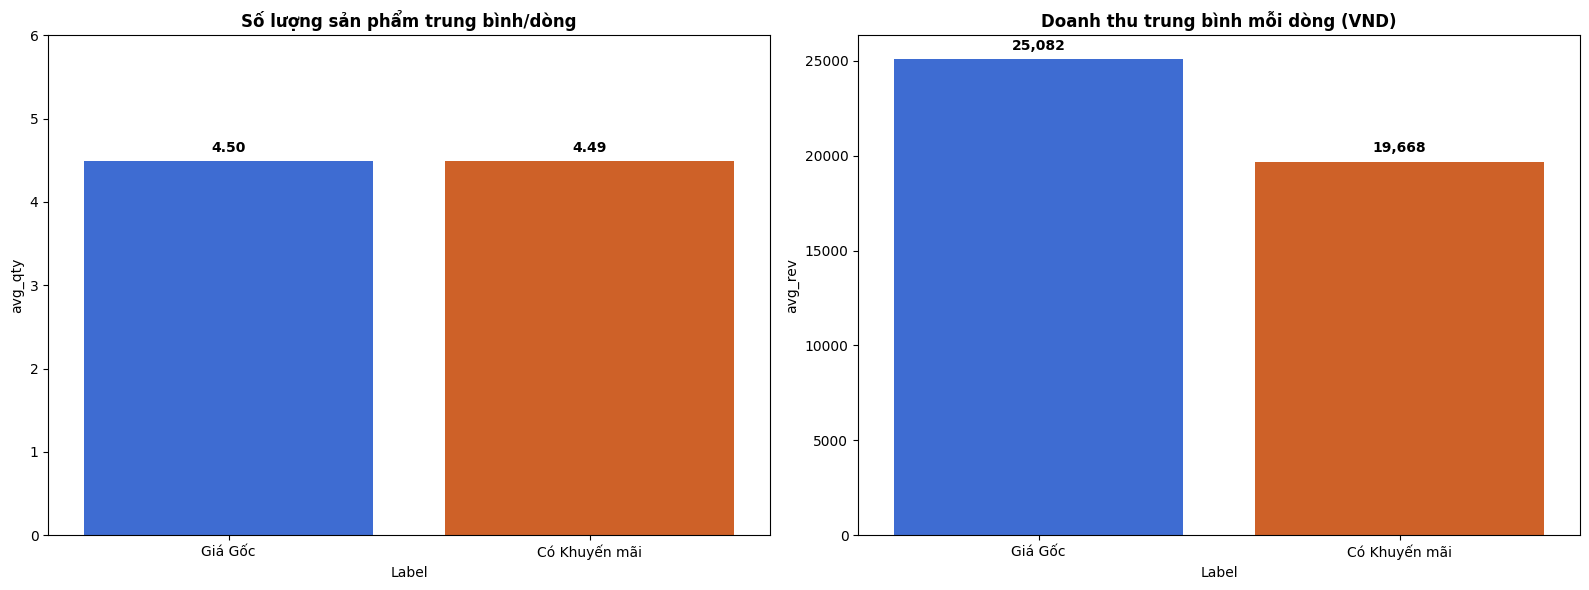

2. PHÂN TÍCH: LÝ DO TRẢ HÀNG & ĐIỂM NÓNG SAI KÍCH CỠ...


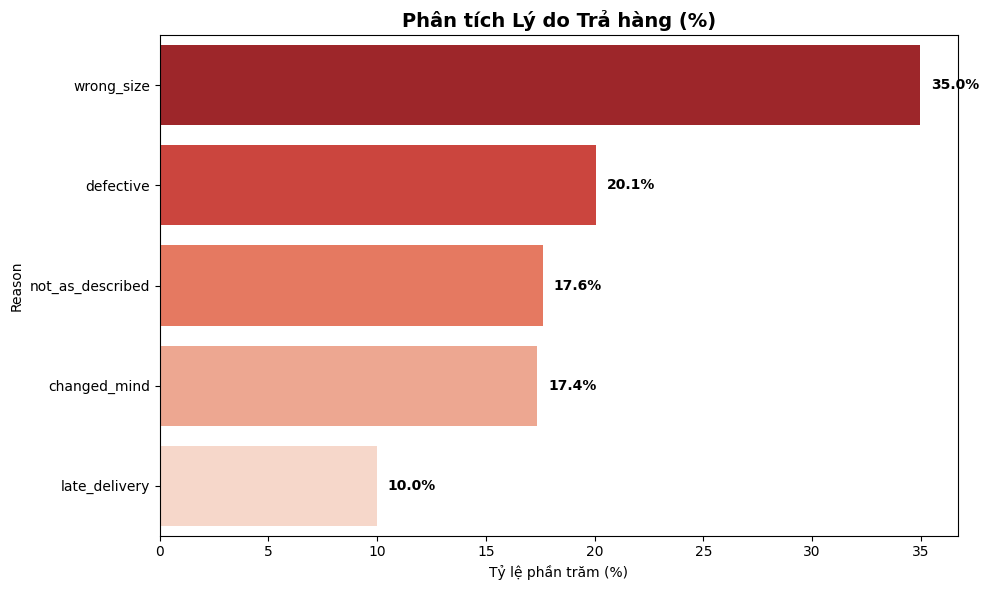

3. PHÂN TÍCH: BIẾN ĐỘNG DANH MỤC 2018-2019


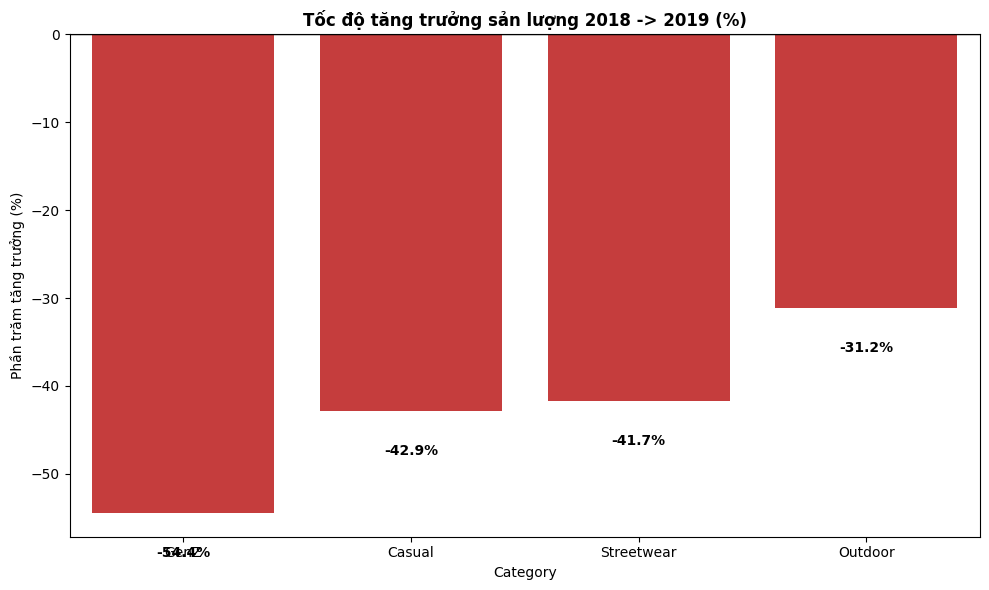

In [35]:
def generate_strategic_insights():
    """Tạo các biểu đồ và phân tích sâu phục vụ trực quan hóa Insight (Phần 2 của Report)"""

    
    # Kế thừa dữ liệu sạch
    try:
        df_ords = orders_clean.copy()
        df_items = order_items_clean.copy()
    except NameError:
        df_ords = orders.copy()
        df_items = order_items.copy()
        
    # INSIGHT 1: HIỆU QUẢ THỰC TẾ CỦA KHUYẾN MÃI (PROMO CANNIBALIZATION)
    print("1. PHÂN TÍCH: HIỆU QUẢ THỰC TẾ CỦA KHUYẾN MÃI")
    
    df_items['has_promo'] = df_items['promo_id'].notna()
    df_items['line_revenue'] = df_items['quantity'] * df_items['unit_price']
    
    promo_compare = df_items.groupby('has_promo').agg(
        avg_qty=('quantity', 'mean'),
        avg_rev=('line_revenue', 'mean')
    ).reset_index()
    
    promo_compare['Label'] = promo_compare['has_promo'].map({True: 'Có Khuyến mãi', False: 'Giá Gốc'})

    # Vẽ biểu đồ Insight 1
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.barplot(data=promo_compare, x='Label', y='avg_qty', ax=ax1, palette=[COLORS[0], COLORS[3]])
    ax1.set_title('Số lượng sản phẩm trung bình/dòng', fontweight='bold')
    ax1.set_ylim(0, 6)
    for i, v in enumerate(promo_compare['avg_qty']):
        ax1.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

    sns.barplot(data=promo_compare, x='Label', y='avg_rev', ax=ax2, palette=[COLORS[0], COLORS[3]])
    ax2.set_title('Doanh thu trung bình mỗi dòng (VND)', fontweight='bold')
    for i, v in enumerate(promo_compare['avg_rev']):
        ax2.text(i, v + 500, f"{v:,.0f}", ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    plt.close()
    

    # INSIGHT 2: LÝ DO TRẢ HÀNG & CƠ HỘI TỐI ƯU (RETURN REASONS)
    
    print("2. PHÂN TÍCH: LÝ DO TRẢ HÀNG & ĐIỂM NÓNG SAI KÍCH CỠ...")
    
    reason_dist = returns['return_reason'].value_counts(normalize=True).reset_index()
    reason_dist.columns = ['Reason', 'Percentage']
    reason_dist['Percentage'] *= 100

    plt.figure(figsize=(10, 6))
    sns.barplot(data=reason_dist, x='Percentage', y='Reason', palette='Reds_r')
    plt.title('Phân tích Lý do Trả hàng (%)', fontweight='bold', fontsize=14)
    plt.xlabel('Tỷ lệ phần trăm (%)')
    
    for i, v in enumerate(reason_dist['Percentage']):
        plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
    plt.close()

   
    # INSIGHT 3: SỰ SỤP ĐỔ CỦA CÁC DANH MỤC TRONG NĂM 2019 (CATEGORY YoY)

    print("3. PHÂN TÍCH: BIẾN ĐỘNG DANH MỤC 2018-2019")
    
    # Nối dữ liệu để lấy Category và Year
    df_cat = pd.merge(df_items, products[['product_id', 'category']], on='product_id')
    df_cat = pd.merge(df_cat, df_ords[['order_id', 'order_date']], on='order_id')
    df_cat['Year'] = df_cat['order_date'].dt.year
    
    cat_yoy = df_cat.groupby(['Year', 'category'])['quantity'].sum().unstack()
    
    if 2018 in cat_yoy.index and 2019 in cat_yoy.index:
        yoy_change = ((cat_yoy.loc[2019] - cat_yoy.loc[2018]) / cat_yoy.loc[2018] * 100).reset_index()
        yoy_change.columns = ['Category', 'Growth']
        yoy_change = yoy_change.sort_values('Growth')

        plt.figure(figsize=(10, 6))
        colors = [COLORS[1] if x < 0 else COLORS[2] for x in yoy_change['Growth']]
        sns.barplot(data=yoy_change, x='Category', y='Growth', palette=colors)
        plt.title('Tốc độ tăng trưởng sản lượng 2018 -> 2019 (%)', fontweight='bold')
        plt.ylabel('Phần trăm tăng trưởng (%)')
        plt.axhline(0, color='black', linewidth=1)
        
        for i, v in enumerate(yoy_change['Growth']):
            plt.text(i, v - 5 if v < 0 else v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()


# Thực thi
generate_strategic_insights()


BUSINESS HYPOTHESES & DEEP DIVE (PRODUCT, COHORT, GEO)

1. PRODUCT INNOVATION (Giả thuyết: Sự thiếu hụt mẫu mã mới gây sụt giảm doanh thu)
------------------------------------------------------------------------------------------------------------------------
  Số lượng mẫu mã MỚI xuất hiện trên thị trường theo từng năm:
    Năm 2012:  528 sản phẩm | ██████████████████████████
    Năm 2013:  155 sản phẩm | ███████
    Năm 2014:  102 sản phẩm | █████
    Năm 2015:   99 sản phẩm | ████
    Năm 2016:   92 sản phẩm | ████
    Năm 2017:  118 sản phẩm | █████
    Năm 2018:   99 sản phẩm | ████
    Năm 2019:  123 sản phẩm | ██████
    Năm 2020:   89 sản phẩm | ████
    Năm 2021:  110 sản phẩm | █████
    Năm 2022:   83 sản phẩm | ████

  => Insight: Nếu số lượng sản phẩm mới sau năm 2018 giảm mạnh, điều này giải thích
     cho cú sập doanh thu 2019 do khách hàng không còn tìm thấy sự đổi mới.

2. CUSTOMER ACQUISITION (Tốc độ thu hút và tỷ lệ chuyển đổi khách hàng)
  Số lượng Khách hàng mới đ

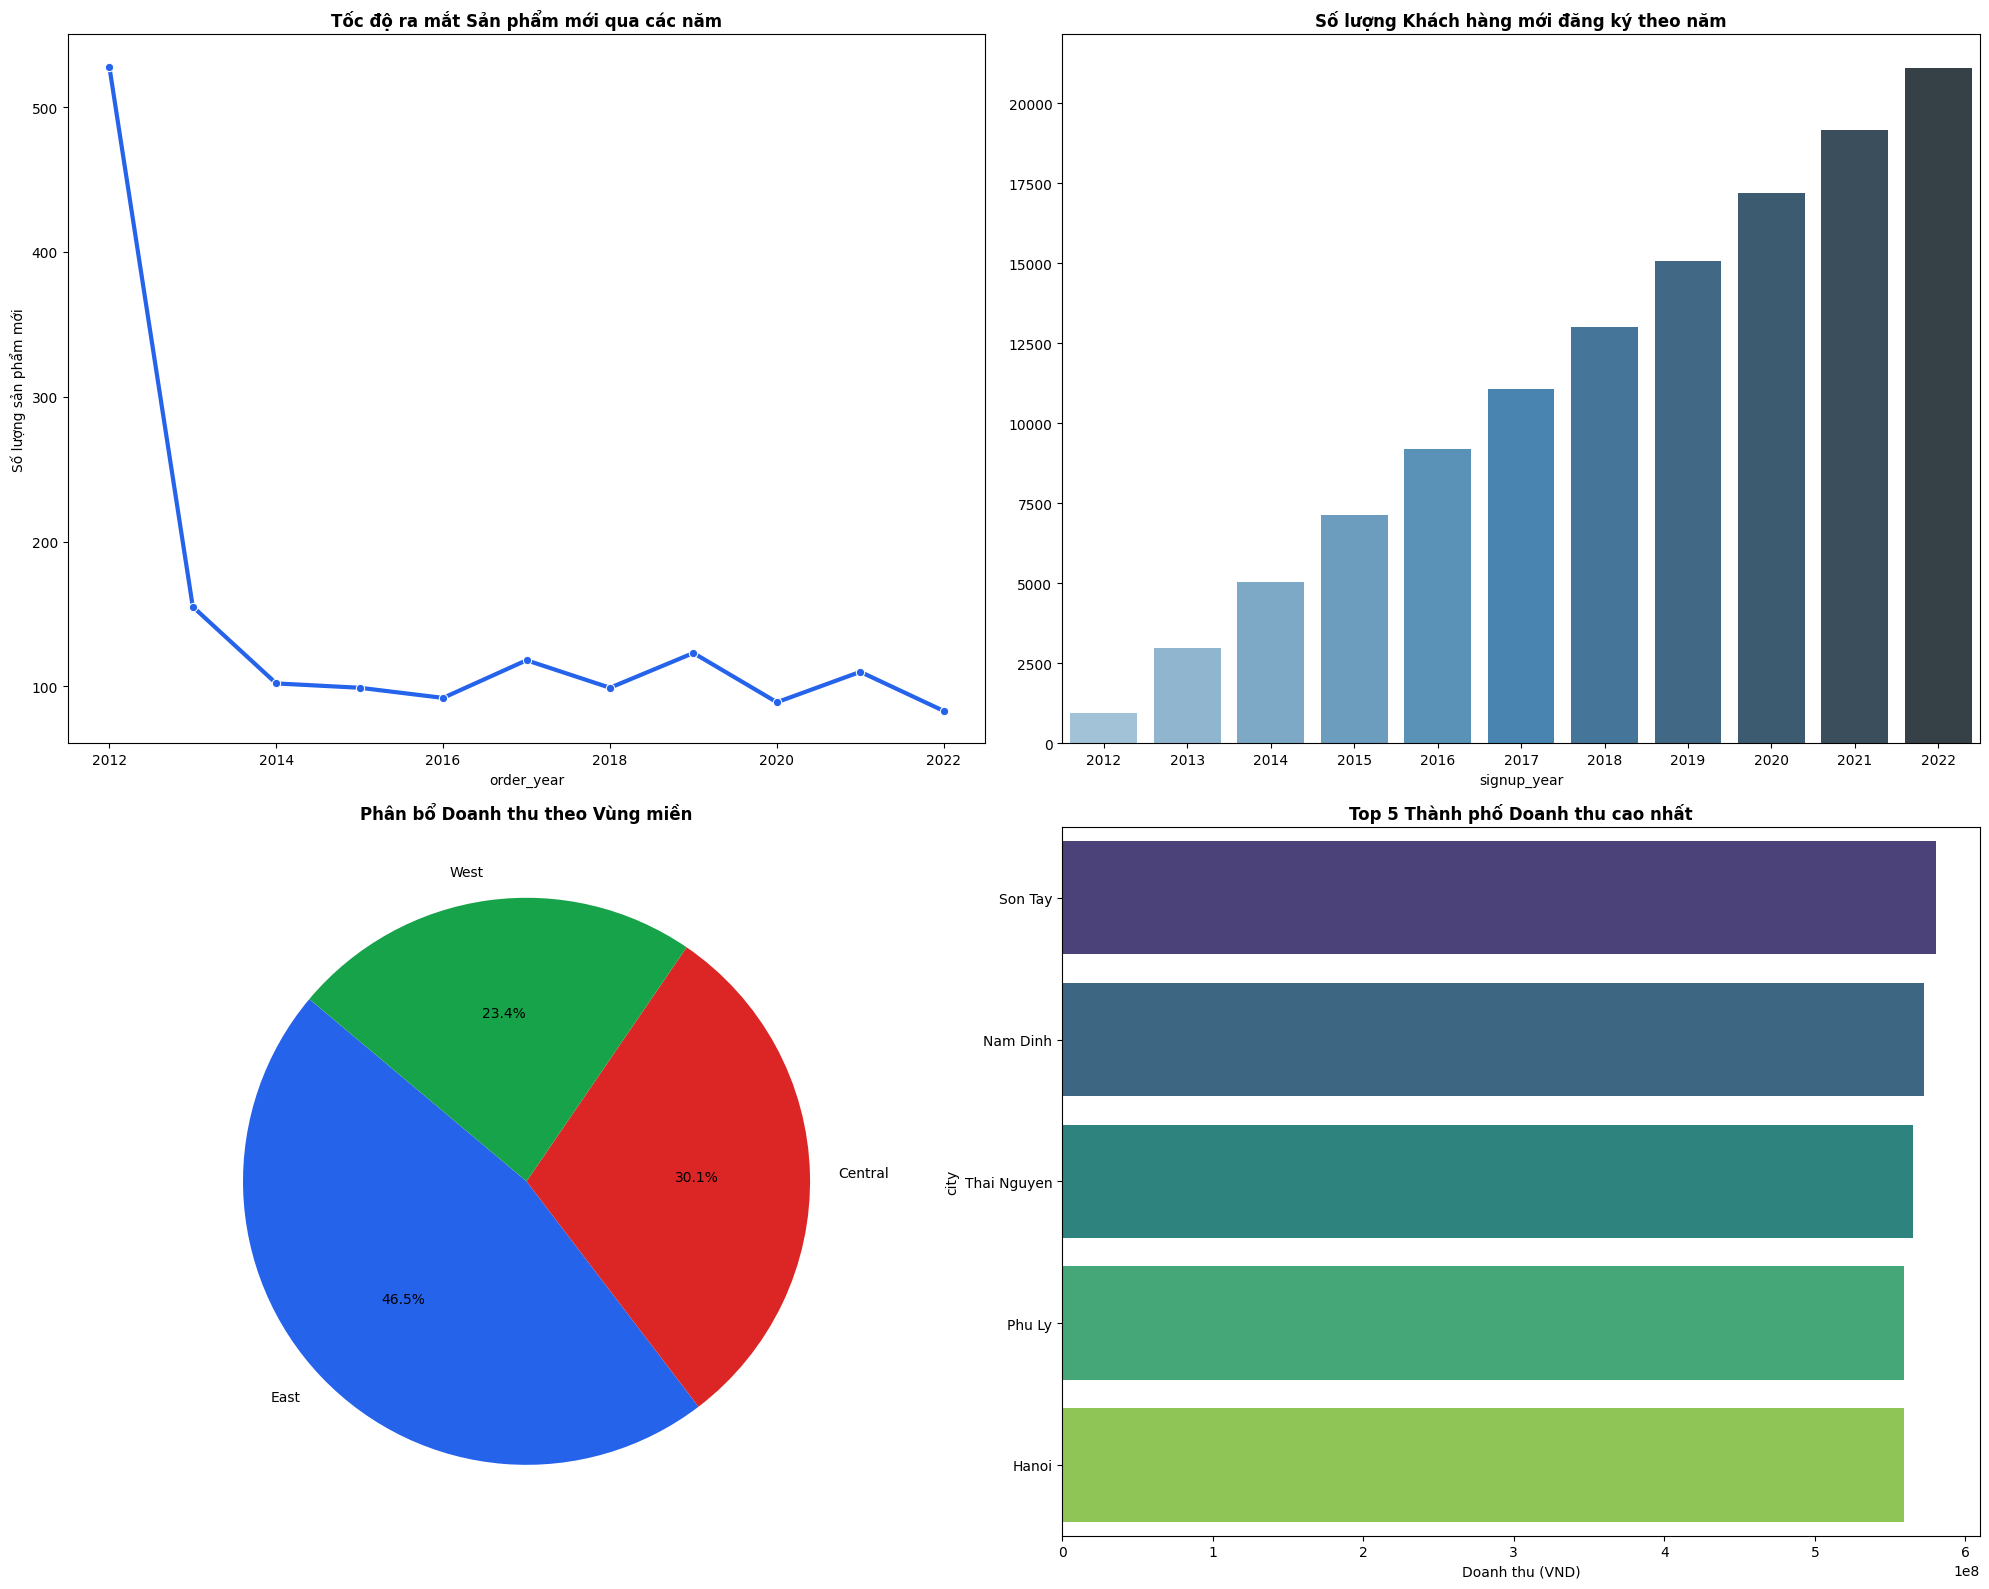

In [45]:
def analyze_business_hypotheses():
    """Kiểm định các giả thuyết kinh doanh về Sản phẩm, Khách hàng và Địa lý (Layer 4)"""
    
    print("\n" + "="*120)
    print("BUSINESS HYPOTHESES & DEEP DIVE (PRODUCT, COHORT, GEO)")
    print("="*120 + "\n")
    
    # Kế thừa dữ liệu đã làm sạch (orders_clean, order_items_clean)
    try:
        df_ords = orders_clean.copy()
        df_items = order_items_clean.copy()
    except NameError:
        print("  [Cảnh báo]: Không tìm thấy dữ liệu sạch. Đang sử dụng dữ liệu thô...")
        df_ords = orders.copy()
        df_items = order_items.copy()
        
    df_ords['order_year'] = df_ords['order_date'].dt.year
    

    # 1. PRODUCT INNOVATION (Tốc độ ra mắt sản phẩm mới)
  
    print("1. PRODUCT INNOVATION (Giả thuyết: Sự thiếu hụt mẫu mã mới gây sụt giảm doanh thu)")
    print("-" * 120)
    
    # Xác định năm ra mắt (Launch Year) của từng sản phẩm dựa trên đơn hàng đầu tiên
    prod_launch = df_items.merge(df_ords[['order_id', 'order_year']], on='order_id')
    launch_years = prod_launch.groupby('product_id')['order_year'].min().reset_index()
    launch_dist = launch_years['order_year'].value_counts().sort_index()
    
    print("  Số lượng mẫu mã MỚI xuất hiện trên thị trường theo từng năm:")
    for year, cnt in launch_dist.items():
        bar = "█" * int(cnt / 20) 
        print(f"    Năm {int(year)}: {cnt:>4} sản phẩm | {bar}")
        
    print("\n  => Insight: Nếu số lượng sản phẩm mới sau năm 2018 giảm mạnh, điều này giải thích")
    print("     cho cú sập doanh thu 2019 do khách hàng không còn tìm thấy sự đổi mới.")

   
    # 2. CUSTOMER ACQUISITION & CONVERSION (Sức hút của nền tảng)

    print(f"\n2. CUSTOMER ACQUISITION (Tốc độ thu hút và tỷ lệ chuyển đổi khách hàng)")

    
    df_cust = customers.copy()
    df_cust['signup_year'] = df_cust['signup_date'].dt.year
    cohort_size = df_cust['signup_year'].value_counts().sort_index()
    
    print("  Số lượng Khách hàng mới đăng ký (Sign-ups) theo năm:")
    for year, cnt in cohort_size.items():
        bar = "█" * int(cnt / 2500)
        print(f"    Năm {int(year)}: {cnt:>6,} users | {bar}")
        
    # Tính tỷ lệ khách hàng thực sự phát sinh đơn hàng (Conversion)
    total_signups = len(df_cust)
    actual_buyers = df_ords['customer_id'].nunique()
    print(f"\n  Tỷ lệ chuyển đổi tổng (Buyer / Total Users): {(actual_buyers/total_signups)*100:.1f}%")

  
    # 3. GEOGRAPHICAL REVENUE (Trọng điểm địa lý)
  
    print(f"\n3. GEOGRAPHICAL ANALYSIS (Xác định vùng động lực doanh thu)")

    
    # Nối dữ liệu để tính doanh thu theo Vùng
    df_geo_rev = df_items.assign(line_rev=df_items['quantity'] * df_items['unit_price'])
    df_geo_rev = df_geo_rev.merge(df_ords[['order_id', 'zip']], on='order_id')
    df_geo_rev = df_geo_rev.merge(geography[['zip', 'region', 'city']], on='zip', how='left')
    
    region_stats = df_geo_rev.groupby('region')['line_rev'].sum().sort_values(ascending=False)
    total_rev = region_stats.sum()
    
    print("  Tỷ trọng Doanh thu theo Vùng (Region):")
    for reg, val in region_stats.items():
        pct = (val / total_rev) * 100
        print(f"    Vùng {reg:10s}: {val/1e9:>8.2f} Tỷ VND ({pct:>5.1f}%)")
        
    # Top 5 Thành phố đóng góp doanh thu lớn nhất
    city_rev = df_geo_rev.groupby('city')['line_rev'].sum().sort_values(ascending=False).head(5)
    print("\n  Top 5 Thành phố (City) gánh vác doanh thu cao nhất:")
    for city, val in city_rev.items():
        pct = (val / total_rev) * 100
        print(f"    {city:15s}: {val/1e9:>8.2f} Tỷ VND ({pct:>5.1f}%)")


    # 4. TRỰC QUAN HÓA (DASHBOARD LAYER 4)

    print(f"\n4. BIỂU ĐỒ PHÂN TÍCH CHIẾN LƯỢC")
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Plot 1: Product Launch Trend
    sns.lineplot(x=launch_dist.index, y=launch_dist.values, marker='o', ax=axes[0,0], color=COLORS[0], linewidth=3)
    axes[0,0].set_title('Tốc độ ra mắt Sản phẩm mới qua các năm', fontweight='bold')
    axes[0,0].set_ylabel('Số lượng sản phẩm mới')
    
    # Plot 2: Customer Signup Trend
    sns.barplot(x=cohort_size.index, y=cohort_size.values, ax=axes[0,1], palette='Blues_d')
    axes[0,1].set_title('Số lượng Khách hàng mới đăng ký theo năm', fontweight='bold')
    
    # Plot 3: Revenue by Region (Pie Chart)
    axes[1,0].pie(region_stats, labels=region_stats.index, autopct='%1.1f%%', startangle=140, colors=COLORS)
    axes[1,0].set_title('Phân bổ Doanh thu theo Vùng miền', fontweight='bold')
    
    # Plot 4: Top Cities Revenue
    sns.barplot(x=city_rev.values, y=city_rev.index, ax=axes[1,1], palette='viridis')
    axes[1,1].set_title('Top 5 Thành phố Doanh thu cao nhất', fontweight='bold')
    axes[1,1].set_xlabel('Doanh thu (VND)')

    plt.tight_layout()
    plot_path = OUTPUT_DIR / 'layer4_business_insights.png'
    plt.show()
    plt.close()


# Thực thi Layer 4
analyze_business_hypotheses()